# Notebook 09b - MVP 4-IW-CC: Context-Conditioned Identity-Weighted Cross-Modal Attention

**Purpose.** Ablation of MVP 4-IW (NB 09) targeting the T2 NotHate regression
that fixed-weight identity attention introduced. NB 09 showed identity
attention raises the prior on hate uniformly, regardless of context, which is
exactly wrong for benign uses of identity vocabulary (news commentary,
in-group reclamation, self-reference). The signature of that failure is a
collapse in T2 NotHate F1 from 0.5685 (MVP 4) to 0.3378 (MVP 4-IW).

## The failure mode being addressed
- Identity-weighted attention from NB 09 fires the same way on identity tokens
  irrespective of whether the surrounding tweet is hateful or benign.
- T2 NotHate F1: **0.5685 (MVP 4) -> 0.3378 (MVP 4-IW)**, a -0.2307 drop.
- The T1 FPR gain (0.2857 vs 0.3071) was paid for by misclassifying benign
  identity-bearing tweets as one of the hate categories.

## The proposed fix
Modulate the identity attention bias by the tweet's VADER negative sentiment
score (range [0, 1], raw, never standardised). Identity tokens inside a
negative-sentiment tweet get the strong attention boost; identity tokens
inside neutral/positive tweets get only a mild boost (the `1 +` floor
keeps the lexicon prior alive even when `vader_neg ~ 0`).

      MVP 4 (NB 08):       logits = (Q @ K^T) / sqrt(d_k)
      MVP 4-IW (NB 09):    logits = (Q @ K^T) / sqrt(d_k) + lambda_id * identity_mask
      MVP 4-IW-CC (this):  logits = (Q @ K^T) / sqrt(d_k) + lambda_id * identity_mask * (1 + alpha * vader_neg)

`lambda_id` and `alpha` are both trainable scalars (init 1.0). The model can
learn to push `alpha -> 0` (collapse back to NB 09 behaviour), keep it near
1.0 (default context-sensitivity), or push it large (heavily context-dependent
weighting).

## Four success criteria (any one or more justifies the variant)
1. **(a) AUC >= MVP 4-IW (0.7359):** no further degradation on T1 discrimination
2. **(b) T2 NotHate F1 >= 0.45:** partial recovery from the NB 09 collapse
3. **(c) FPR within 0.02 of MVP 4-IW (0.2857):** preserve the NB 09 FPR win
4. **(d) alpha > 0.1 at convergence:** the context-modulation mechanism is
   actively used, not pruned away

## Locked decisions (identical to NB 09 except for the one architectural change)
- Frozen: text encoder + Run-D LoRA, CLIP vision + MVP 2 LoRA + visual + image projections
- Trainable: Branch C MLP, IW-CC cross-attention (Q/K/V/out + `lambda_id` + `alpha`),
  LayerNorm, gate, three 256-d projections, fresh T1/T2 heads
- `lambda_id` init = 1.0; `alpha` init = 1.0
- 5 epochs, entropy_weight = 0.05, loss = 0.7 T1 + 0.3 T2 - 0.05 H(gates)
- T2 loss masked to `t2_valid = True`
- `vader_neg` used in the bias is the RAW value from `structured_features.csv`,
  NOT the z-scored copy that feeds Branch C (which gets all 9 features unchanged
  for consistency with NB 09)

In [1]:
import os, sys, json, random, gc, time, shutil, math, re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (roc_auc_score, f1_score, precision_score,
                              recall_score, confusion_matrix)
from sklearn.utils.class_weight import compute_class_weight
from transformers import (AutoTokenizer, AutoModel,
                          CLIPVisionModel, CLIPModel, CLIPImageProcessor,
                          get_cosine_schedule_with_warmup)
from peft import PeftModel

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device, '|', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU only')
if torch.cuda.is_available():
    total_gb = torch.cuda.get_device_properties(0).total_memory / 1024**3
    alloc_gb = torch.cuda.memory_allocated() / 1024**3
    print(f'gpu total: {total_gb:.2f} GB | allocated now: {alloc_gb:.2f} GB')

HPARAMS = dict(
    max_len=128,
    image_size=224,
    batch_size=16,
    epochs=5,
    struct_lr=1e-3,
    gate_lr=1e-3,
    crossattn_lr=1e-3,
    proj_lr=1e-3,
    head_lr=1e-3,
    lr=1e-3,
    lambda_id_init=1.0,
    alpha_init=1.0,                # NEW for MVP 4-IW-CC
    warmup_ratio=0.1,
    gamma=2.0,
    grad_accum_steps=4,
    threshold=0.5,
    t1_weight=0.7,
    t2_weight=0.3,
    entropy_weight=0.05,
    collapse_threshold=0.5,
    gpu_warn_gb=14.0,
    weight_decay=0.01,
    dropout=0.1,
    struct_hidden=32,
    fusion_dim=256,
    n_struct_features=9,
    crossattn_heads=8,
    crossattn_dropout=0.1,
    text_base='cardiffnlp/twitter-roberta-base-2022-154m',
    text_adapter='models/roberta_mvp1_d',
    clip_model='openai/clip-vit-base-patch16',
    mvp2_best_dir='models/mvp2_naive_concat_best',
    mvp3_best_dir='models/mvp3_three_branch_best',
    lexicon_path='data/processed/identity_lexicon.json',
    prior_hate=0.2468,
    prior_nothate=0.7532,
    n_t2_classes=6,
    seed=SEED,
)
for k, v in HPARAMS.items():
    print(f'  {k}: {v}')

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
LABELS_CSV = ROOT / 'data' / 'processed' / 'labels_parsed.csv'
STRUCT_CSV = ROOT / 'data' / 'processed' / 'structured_features.csv'
SPLITS_DIR = ROOT / 'data' / 'MMHS150K' / 'splits'
IMG_DIR    = ROOT / 'data' / 'MMHS150K' / 'img_resized'
TEXT_ADAPTER_DIR = ROOT / HPARAMS['text_adapter']
MVP2_BEST_DIR    = ROOT / HPARAMS['mvp2_best_dir']
MVP3_BEST_DIR    = ROOT / HPARAMS['mvp3_best_dir']
LEXICON_PATH     = ROOT / HPARAMS['lexicon_path']
OUT_DIR   = ROOT / 'outputs'
MODEL_DIR = ROOT / 'models' / 'mvp4_iwcc_attention'
BEST_DIR  = ROOT / 'models' / 'mvp4_iwcc_attention_best'
for d in [OUT_DIR, MODEL_DIR, BEST_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print('ROOT:', ROOT)
for p, name in [(LABELS_CSV, 'LABELS_CSV'), (STRUCT_CSV, 'STRUCT_CSV'),
                 (SPLITS_DIR, 'SPLITS_DIR'), (IMG_DIR, 'IMG_DIR'),
                 (TEXT_ADAPTER_DIR, 'TEXT_ADAPTER_DIR'),
                 (MVP2_BEST_DIR, 'MVP2_BEST_DIR'),
                 (MVP3_BEST_DIR, 'MVP3_BEST_DIR'),
                 (LEXICON_PATH, 'LEXICON_PATH')]:
    print(f'  {name:<18} exists={p.exists()}  -> {p}')

device: cuda | NVIDIA L4
gpu total: 22.03 GB | allocated now: 0.00 GB
  max_len: 128
  image_size: 224
  batch_size: 16
  epochs: 5
  struct_lr: 0.001
  gate_lr: 0.001
  crossattn_lr: 0.001
  proj_lr: 0.001
  head_lr: 0.001
  lr: 0.001
  lambda_id_init: 1.0
  alpha_init: 1.0
  warmup_ratio: 0.1
  gamma: 2.0
  grad_accum_steps: 4
  threshold: 0.5
  t1_weight: 0.7
  t2_weight: 0.3
  entropy_weight: 0.05
  collapse_threshold: 0.5
  gpu_warn_gb: 14.0
  weight_decay: 0.01
  dropout: 0.1
  struct_hidden: 32
  fusion_dim: 256
  n_struct_features: 9
  crossattn_heads: 8
  crossattn_dropout: 0.1
  text_base: cardiffnlp/twitter-roberta-base-2022-154m
  text_adapter: models/roberta_mvp1_d
  clip_model: openai/clip-vit-base-patch16
  mvp2_best_dir: models/mvp2_naive_concat_best
  mvp3_best_dir: models/mvp3_three_branch_best
  lexicon_path: data/processed/identity_lexicon.json
  prior_hate: 0.2468
  prior_nothate: 0.7532
  n_t2_classes: 6
  seed: 42
ROOT: /teamspace/studios/this_studio/HateFusion
 

In [2]:
df_lab = pd.read_csv(LABELS_CSV)
df_str = pd.read_csv(STRUCT_CSV)
print(f'labels CSV   shape: {df_lab.shape}, nulls per col:')
print(df_lab.isna().sum().to_string())
print(f'\nstructured CSV shape: {df_str.shape}, nulls per col:')
print(df_str.isna().sum().to_string())

# CRITICAL: confirm raw vader_neg is in [0,1] (pre-flight V1 passed; assert again here)
assert df_str['vader_neg'].min() >= 0.0, 'raw vader_neg must be >= 0'
assert df_str['vader_neg'].max() <= 1.0, 'raw vader_neg must be <= 1'
assert df_str['vader_neg'].isna().sum() == 0, 'raw vader_neg must have no nulls'
print(f"\nraw vader_neg stats (used unmodified for context modulation):")
print(f"  min={df_str['vader_neg'].min():.4f}  max={df_str['vader_neg'].max():.4f}  "
      f"mean={df_str['vader_neg'].mean():.4f}  std={df_str['vader_neg'].std():.4f}")

df = df_lab.merge(df_str, on='tweet_id', how='inner')
print(f'\nmerged shape: {df.shape}')

def load_split_ids(path):
    return {int(line.strip().split('.')[0]) for line in path.read_text().splitlines() if line.strip()}

train_ids = load_split_ids(SPLITS_DIR / 'train_ids.txt')
val_ids   = load_split_ids(SPLITS_DIR / 'val_ids.txt')
test_ids  = load_split_ids(SPLITS_DIR / 'test_ids.txt')
print(f'\nofficial splits: train {len(train_ids):,}  val {len(val_ids):,}  test {len(test_ids):,}')

df['split'] = df['tweet_id'].map(lambda x:
    'train' if x in train_ids else ('val' if x in val_ids else ('test' if x in test_ids else None)))
print('split distribution:')
print(df['split'].value_counts(dropna=False).to_string())

for sp in ['train', 'val', 'test']:
    sub = df[df['split'] == sp]
    print(f'\n--- {sp} (n={len(sub):,}) ---')
    print(f'  T1 hate fraction: {sub["T1"].mean():.4f}')
    print(f'  t2_valid count:   {int(sub["t2_valid"].sum()):,}')
    print(f'  T2 NaN count:     {int(sub["T2"].isna().sum()):,}')

labels CSV   shape: (149819, 10), nulls per col:
tweet_id            0
tweet_text          0
img_filename        0
labels              0
labels_str          0
T1                  0
T2              11710
T3                  0
n_annotators        0
t2_valid            0

structured CSV shape: (149819, 10), nulls per col:
tweet_id              0
vader_neg             0
vader_neu             0
n_emoji               0
ocr_present           0
n_hashtags            0
ocr_len               0
hate_keyword_count    0
profanity_count       0
n_mentions            0

raw vader_neg stats (used unmodified for context modulation):
  min=0.0000  max=0.9600  mean=0.1748  std=0.1876

merged shape: (149819, 19)

official splits: train 134,823  val 5,000  test 10,000


split distribution:
split
train    134820
test      10000
val        4999

--- train (n=134,820) ---
  T1 hate fraction: 0.2186
  t2_valid count:   125,501
  T2 NaN count:     9,319

--- val (n=4,999) ---
  T1 hate fraction: 0.5001
  t2_valid count:   4,197
  T2 NaN count:     802

--- test (n=10,000) ---
  T1 hate fraction: 0.5001
  t2_valid count:   8,411
  T2 NaN count:     1,589


In [3]:
with open(LEXICON_PATH, 'r') as f:
    lex_payload = json.load(f)
LEXICON_TOKENS = {entry['token'].lower() for entry in lex_payload['tokens']}
print(f'identity lexicon version: {lex_payload["version"]}')
print(f'source: {lex_payload["source"]}')
print(f'n_tokens: {lex_payload["n_tokens"]:,}')
print(f'n_communities: {lex_payload["n_communities"]}')
print(f'communities: {", ".join(lex_payload["communities_included"])}')
print(f'mmhs150k_train_coverage_fraction: {lex_payload["mmhs150k_train_coverage_fraction"]:.4f}')

import random as _r
_r.seed(SEED)
sample_tokens = _r.sample(sorted(LEXICON_TOKENS), 20)
print(f'\n20 sample lexicon tokens (lowercase): {sample_tokens}')

identity lexicon version: 1.0
source: HateXplain (Mathew et al. 2021), https://github.com/hate-alert/HateXplain
n_tokens: 1,177
n_communities: 15
communities: African, Arab, Asian, Caucasian, Christian, Disability, Hindu, Hispanic, Homosexual, Indian, Islam, Jewish, Men, Refugee, Women
mmhs150k_train_coverage_fraction: 0.8980

20 sample lexicon tokens (lowercase): ['countries', 'arrested', 'justin', 'immigrant', 'hire', 'doesnt', 'concentration', 'wanna', 'chink', 'religion', 'attitude', 'atheists', 'citizenship', 'herself', 'homos', 'term', 'asian', 'wind', 'goats', 'refugees']


In [4]:
STD_STATS_PATH = MVP3_BEST_DIR / 'standardisation_stats.json'
with open(STD_STATS_PATH, 'r') as f:
    STRUCT_STATS = json.load(f)
print(f'loaded standardisation stats from {STD_STATS_PATH}')
STRUCT_FEATURES = STRUCT_STATS['feature_order']
BINARY_SET = set(STRUCT_STATS['binary_features'])
OCR_LEN_CLIP = float(STRUCT_STATS.get('ocr_len_clip', 389.0))
print(f'feature_order ({len(STRUCT_FEATURES)}): {STRUCT_FEATURES}')
print(f'binary_features: {sorted(BINARY_SET)}')
print(f'ocr_len_clip: {OCR_LEN_CLIP}')
print(f'\nper-feature standardisation (Branch C inputs — vader_neg is z-scored here):')
for feat in STRUCT_FEATURES:
    if feat in BINARY_SET:
        print(f'  {feat:<22} identity (binary in [0,1])')
    elif feat == 'ocr_len':
        m = STRUCT_STATS['feature_means'][feat]; s = STRUCT_STATS['feature_stds'][feat]
        print(f'  {feat:<22} clip @ {OCR_LEN_CLIP} then z(mean={m:.4f}, std={s:.4f})')
    else:
        m = STRUCT_STATS['feature_means'][feat]; s = STRUCT_STATS['feature_stds'][feat]
        print(f'  {feat:<22} z-score (mean={m:.4f}, std={s:.4f})')
assert len(STRUCT_FEATURES) == HPARAMS['n_struct_features'], 'feature count mismatch'

def standardise_struct(row_dict):
    out = []
    for feat in STRUCT_FEATURES:
        v = float(row_dict[feat])
        if feat in BINARY_SET:
            out.append(v)
        elif feat == 'ocr_len':
            v = min(v, OCR_LEN_CLIP)
            m = STRUCT_STATS['feature_means'][feat]; s = STRUCT_STATS['feature_stds'][feat]
            out.append((v - m) / s)
        else:
            m = STRUCT_STATS['feature_means'][feat]; s = STRUCT_STATS['feature_stds'][feat]
            out.append((v - m) / s)
    return out

loaded standardisation stats from /teamspace/studios/this_studio/HateFusion/models/mvp3_three_branch_best/standardisation_stats.json
feature_order (9): ['vader_neg', 'vader_neu', 'n_emoji', 'hate_keyword_count', 'ocr_present', 'profanity_count', 'n_hashtags', 'ocr_len', 'n_mentions']
binary_features: ['ocr_present']
ocr_len_clip: 389.0

per-feature standardisation (Branch C inputs — vader_neg is z-scored here):
  vader_neg              z-score (mean=0.1725, std=0.1866)
  vader_neu              z-score (mean=0.7298, std=0.2067)
  n_emoji                z-score (mean=0.5630, std=1.5614)
  hate_keyword_count     z-score (mean=0.7224, std=0.4846)
  ocr_present            identity (binary in [0,1])
  profanity_count        z-score (mean=0.9150, std=0.8332)
  n_hashtags             z-score (mean=0.2024, std=0.7893)
  ocr_len                clip @ 389.0 then z(mean=29.3807, std=68.8518)
  n_mentions             z-score (mean=0.5289, std=0.8290)


In [5]:
def img_path_for(tid):
    return IMG_DIR / f'{int(tid)}.jpg'

missing_per_split = {}
for sp in ['train', 'val', 'test']:
    sub = df[df['split'] == sp]
    keep_mask = sub['tweet_id'].map(lambda t: img_path_for(t).exists())
    n_missing = int((~keep_mask).sum())
    missing_per_split[sp] = n_missing
    df.loc[(df['split'] == sp) & ~df['tweet_id'].map(lambda t: img_path_for(t).exists()), 'split'] = None

print('image-existence drop counts:')
for sp, n in missing_per_split.items():
    print(f'  {sp}: {n} dropped')

print('\nfinal split sizes (after image drop):')
for sp in ['train', 'val', 'test']:
    sub = df[df['split'] == sp]
    print(f'  {sp}: {len(sub):,} | hate {sub["T1"].mean():.4f} | t2_valid {int(sub["t2_valid"].sum()):,}')

image-existence drop counts:
  train: 0 dropped
  val: 0 dropped
  test: 0 dropped

final split sizes (after image drop):
  train: 134,820 | hate 0.2186 | t2_valid 125,501
  val: 4,999 | hate 0.5001 | t2_valid 4,197
  test: 10,000 | hate 0.5001 | t2_valid 8,411


In [6]:
# RoBERTa tokenizer (fast) is needed for return_offsets_mapping
tokenizer = AutoTokenizer.from_pretrained(HPARAMS['text_base'], use_fast=True)
image_processor = CLIPImageProcessor.from_pretrained(HPARAMS['clip_model'])

WORD_RE = re.compile(r"[a-z0-9_']+", re.UNICODE)

def compute_identity_mask(text, max_len):
    text_lower = (text or '').lower()
    id_word_spans = [(m.start(), m.end()) for m in WORD_RE.finditer(text_lower)
                     if m.group() in LEXICON_TOKENS]
    enc = tokenizer(text_lower, padding='max_length', truncation=True, max_length=max_len,
                    return_offsets_mapping=True, return_tensors='pt')
    offsets = enc['offset_mapping'][0]
    attn = enc['attention_mask'][0]
    mask = torch.zeros(max_len, dtype=torch.float32)
    if not id_word_spans:
        return mask, enc['input_ids'][0], attn
    for i in range(max_len):
        if attn[i] == 0:
            continue
        tok_start, tok_end = offsets[i].tolist()
        if tok_start == 0 and tok_end == 0:
            continue  # special token
        for ws, we in id_word_spans:
            if tok_start < we and tok_end > ws:
                mask[i] = 1.0
                break
    return mask, enc['input_ids'][0], attn


class MMHS150KIWCCDataset(Dataset):
    '''MVP 4-IW dataset extended with a per-sample RAW vader_neg field
    used by the IW-CC cross-attention bias modulation.

    Returns:
      input_ids, attention_mask, identity_mask, pixel_values, structured (z-scored 9-d),
      vader_neg_raw (float in [0, 1]),  <-- NEW
      t1_label, t2_label, t2_valid_mask, tweet_id
    '''
    def __init__(self, df_subset, struct_stats, max_len, image_size, assert_raw_n=100):
        self.records = df_subset.reset_index(drop=True).to_dict('records')
        self.max_len = max_len
        self.image_size = image_size
        self.assert_raw_n = int(assert_raw_n)
        self.seen = 0

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        rec = self.records[idx]
        text = str(rec.get('tweet_text') or '')
        identity_mask, input_ids, attention_mask = compute_identity_mask(text, self.max_len)

        img = Image.open(img_path_for(rec['tweet_id'])).convert('RGB')
        px = image_processor(images=img, return_tensors='pt')['pixel_values'].squeeze(0)

        struct = torch.tensor(standardise_struct(rec), dtype=torch.float32)
        vader_raw = float(rec['vader_neg'])     # RAW, never standardised
        if self.seen < self.assert_raw_n:
            assert 0.0 <= vader_raw <= 1.0, f'vader_neg out of [0,1] at idx {idx}: {vader_raw}'
            self.seen += 1
        t1_label = torch.tensor(int(rec['T1']), dtype=torch.float32)
        t2_raw = rec['T2']
        t2_valid_flag = bool(rec.get('t2_valid', False)) and not (isinstance(t2_raw, float) and math.isnan(t2_raw))
        t2_label = torch.tensor(int(t2_raw) if t2_valid_flag else 0, dtype=torch.long)
        t2_valid_mask = torch.tensor(1.0 if t2_valid_flag else 0.0, dtype=torch.float32)

        return {
            'input_ids':      input_ids,
            'attention_mask': attention_mask,
            'identity_mask':  identity_mask,
            'pixel_values':   px,
            'structured':     struct,
            'vader_neg_raw':  torch.tensor(vader_raw, dtype=torch.float32),
            't1_label':       t1_label,
            't2_label':       t2_label,
            't2_valid_mask':  t2_valid_mask,
            'tweet_id':       torch.tensor(int(rec['tweet_id']), dtype=torch.int64),
        }


train_df = df[df['split'] == 'train'].copy()
val_df   = df[df['split'] == 'val'].copy()
test_df  = df[df['split'] == 'test'].copy()
print(f'split sizes -> train {len(train_df):,}  val {len(val_df):,}  test {len(test_df):,}')

train_ds = MMHS150KIWCCDataset(train_df, STRUCT_STATS, HPARAMS['max_len'], HPARAMS['image_size'])
val_ds   = MMHS150KIWCCDataset(val_df,   STRUCT_STATS, HPARAMS['max_len'], HPARAMS['image_size'])
test_ds  = MMHS150KIWCCDataset(test_df,  STRUCT_STATS, HPARAMS['max_len'], HPARAMS['image_size'])

train_loader = DataLoader(train_ds, batch_size=HPARAMS['batch_size'], shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=HPARAMS['batch_size'], shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=HPARAMS['batch_size'], shuffle=False, num_workers=2, pin_memory=True)

# First batch sanity check
b0 = next(iter(train_loader))
id_frac = (b0['identity_mask'].sum(dim=-1) / b0['attention_mask'].sum(dim=-1).clamp(min=1)).numpy()
v_raw = b0['vader_neg_raw'].numpy()
print(f'\nFirst batch sanity check:')
print(f'  input_ids shape:      {tuple(b0["input_ids"].shape)}')
print(f'  identity_mask shape:  {tuple(b0["identity_mask"].shape)}')
print(f'  vader_neg_raw shape:  {tuple(b0["vader_neg_raw"].shape)}')
print(f'  per-sample identity-token fraction (mean): {id_frac.mean():.4f}')
print(f'  vader_neg_raw distribution in batch:')
print(f'    min={v_raw.min():.4f}  mean={v_raw.mean():.4f}  max={v_raw.max():.4f}  std={v_raw.std():.4f}')
print(f'    sample values: {v_raw[:8].tolist()}')
assert (v_raw >= 0.0).all() and (v_raw <= 1.0).all(), 'vader_neg_raw must stay in [0,1]'

split sizes -> train 134,820  val 4,999  test 10,000



First batch sanity check:
  input_ids shape:      (16, 128)
  identity_mask shape:  (16, 128)
  vader_neg_raw shape:  (16,)
  per-sample identity-token fraction (mean): 0.0908
  vader_neg_raw distribution in batch:
    min=0.0000  mean=0.2204  max=0.6490  std=0.1927
    sample values: [0.3160000145435333, 0.5239999890327454, 0.2540000081062317, 0.18199999630451202, 0.23100000619888306, 0.0, 0.6489999890327454, 0.15700000524520874]


In [7]:
# Per-train T1 pos_weight (CLAUDE.md sec 9)
n_pos = int(train_df['T1'].sum())
n_neg = int((train_df['T1'] == 0).sum())
pos_weight_value = float(n_neg / max(n_pos, 1))
print(f'T1 pos_weight (train neg/pos): {pos_weight_value:.4f}')

t2_train_valid = train_df[train_df['t2_valid'] == True]
classes = list(range(HPARAMS['n_t2_classes']))
t2_class_weights = compute_class_weight('balanced', classes=np.array(classes),
                                         y=t2_train_valid['T2'].astype(int).values)
t2_class_weights = torch.tensor(t2_class_weights, dtype=torch.float32)
print('T2 class weights:')
for c, w in zip(classes, t2_class_weights.tolist()):
    print(f'  class {c}: weight {w:.4f}')

def focal_bce_with_pos_weight(logits, targets, pos_weight, gamma=2.0):
    p = torch.sigmoid(logits)
    pt = torch.where(targets == 1, p, 1 - p)
    weight = torch.where(targets == 1, pos_weight, torch.tensor(1.0, device=logits.device, dtype=logits.dtype))
    bce = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
    return (weight * (1 - pt) ** gamma * bce).mean()

def focal_ce_masked(logits, targets, valid_mask, class_weights, gamma=2.0):
    log_probs = F.log_softmax(logits, dim=-1)
    probs = log_probs.exp()
    nll = -log_probs.gather(1, targets.unsqueeze(1)).squeeze(1)
    pt  = probs.gather(1, targets.unsqueeze(1)).squeeze(1).clamp(1e-8, 1 - 1e-8)
    w   = class_weights.to(logits.device)[targets]
    per_sample = w * (1 - pt) ** gamma * nll
    masked = per_sample * valid_mask
    return masked.sum() / valid_mask.sum().clamp(min=1)

def gate_entropy(gates, eps=1e-8):
    H = -(gates * torch.log(gates + eps)).sum(dim=-1)
    return H.mean()

pos_weight_tensor = torch.tensor(pos_weight_value, dtype=torch.float32, device=device)
print(f'\nloss weights:  t1={HPARAMS["t1_weight"]}  t2={HPARAMS["t2_weight"]}  entropy={HPARAMS["entropy_weight"]} (-H sign)')
print(f'lambda_id_init = {HPARAMS["lambda_id_init"]}   alpha_init = {HPARAMS["alpha_init"]}')

T1 pos_weight (train neg/pos): 3.5739
T2 class weights:
  class 0: weight 0.1986
  class 1: weight 2.2006
  class 2: weight 7.4971
  class 3: weight 6.7758
  class 4: weight 160.8987
  class 5: weight 4.5031

loss weights:  t1=0.7  t2=0.3  entropy=0.05 (-H sign)
lambda_id_init = 1.0   alpha_init = 1.0


In [8]:
class IWCCMultiheadAttention(nn.Module):
    '''Cross-attention with context-conditioned identity-bias on attention logits.

    logits = (Q @ K^T)/sqrt(d_k) + lambda_id * identity_mask * (1 + alpha * vader_neg)

    Both lambda_id and alpha are scalar trainable parameters. vader_neg is the
    RAW per-sample VADER negative-sentiment score in [0, 1] (NOT standardised).
    '''
    def __init__(self, embed_dim=768, num_heads=8, dropout=0.1,
                 lambda_id_init=1.0, alpha_init=1.0):
        super().__init__()
        assert embed_dim % num_heads == 0
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.head_dim  = embed_dim // num_heads
        self.q_proj   = nn.Linear(embed_dim, embed_dim)
        self.k_proj   = nn.Linear(embed_dim, embed_dim)
        self.v_proj   = nn.Linear(embed_dim, embed_dim)
        self.out_proj = nn.Linear(embed_dim, embed_dim)
        self.attn_dropout = nn.Dropout(dropout)
        self.lambda_id = nn.Parameter(torch.tensor(float(lambda_id_init)))
        self.alpha     = nn.Parameter(torch.tensor(float(alpha_init)))

    def forward(self, query, key, value, identity_mask=None, vader_neg=None,
                key_padding_mask=None, return_attn=False):
        # query: (B, Lq, E); key/value: (B, Lk, E)
        # identity_mask: (B, Lk) float, 1.0 at identity-token positions
        # vader_neg: (B,) float in [0, 1] — RAW
        # key_padding_mask: (B, Lk) bool, True at PAD positions
        B, Lq, E = query.shape
        Lk = key.shape[1]
        Q = self.q_proj(query).view(B, Lq, self.num_heads, self.head_dim).transpose(1, 2)
        K = self.k_proj(key  ).view(B, Lk, self.num_heads, self.head_dim).transpose(1, 2)
        V = self.v_proj(value).view(B, Lk, self.num_heads, self.head_dim).transpose(1, 2)
        scale  = 1.0 / math.sqrt(self.head_dim)
        logits = (Q @ K.transpose(-2, -1)) * scale            # (B, H, Lq, Lk)
        if identity_mask is not None:
            id_m = identity_mask.to(logits.dtype)              # (B, Lk)
            if vader_neg is not None:
                # context factor: (B, 1) — broadcasts across Lk
                ctx = (1.0 + self.alpha * vader_neg.to(logits.dtype)).unsqueeze(-1)
            else:
                ctx = torch.ones_like(id_m[:, :1])
            id_bias = (self.lambda_id * id_m * ctx).unsqueeze(1).unsqueeze(2)  # (B,1,1,Lk)
            logits = logits + id_bias
        if key_padding_mask is not None:
            kpm = key_padding_mask.unsqueeze(1).unsqueeze(2)
            logits = logits.masked_fill(kpm, float('-inf'))
        attn = F.softmax(logits, dim=-1)
        attn = self.attn_dropout(attn)
        out  = attn @ V
        out  = out.transpose(1, 2).contiguous().view(B, Lq, E)
        out  = self.out_proj(out)
        if return_attn:
            return out, attn
        return out, None


class MVP4IWCCModel(nn.Module):
    def __init__(self,
                 text_base, text_adapter_dir,
                 clip_model_name, mvp2_best_dir,
                 n_struct=9, struct_hidden=32, fusion_dim=256,
                 n_t2_classes=6, dropout=0.1,
                 crossattn_heads=8, crossattn_dropout=0.1,
                 lambda_id_init=1.0, alpha_init=1.0):
        super().__init__()
        self.fusion_dim = fusion_dim
        self.struct_hidden = struct_hidden

        # TEXT (frozen) ------------------------------------------------------
        base_text = AutoModel.from_pretrained(text_base)
        self.text_encoder = PeftModel.from_pretrained(base_text, text_adapter_dir, is_trainable=False)
        for p in self.text_encoder.parameters():
            p.requires_grad = False
        self.text_encoder.eval()

        # IMAGE (frozen) -----------------------------------------------------
        clip_full = CLIPModel.from_pretrained(clip_model_name)
        vis_proj_weight = clip_full.visual_projection.weight.detach().clone()
        del clip_full; gc.collect()
        vision_base = CLIPVisionModel.from_pretrained(clip_model_name)
        self.vision_encoder = PeftModel.from_pretrained(vision_base, mvp2_best_dir, is_trainable=False)
        for p in self.vision_encoder.parameters():
            p.requires_grad = False
        self.vision_encoder.eval()
        clip_hidden = vision_base.config.hidden_size  # 768
        self.visual_projection_to_512 = nn.Linear(clip_hidden, 512, bias=False)
        self.visual_projection_to_512.weight.data = vis_proj_weight
        for p in self.visual_projection_to_512.parameters():
            p.requires_grad = False
        self.image_projection = nn.Linear(512, 768)
        rest = torch.load(Path(mvp2_best_dir) / 'rest.pt', map_location='cpu', weights_only=False)
        self.image_projection.load_state_dict(rest['image_projection'])
        for p in self.image_projection.parameters():
            p.requires_grad = False
        del rest

        # STRUCTURED (trainable) ---------------------------------------------
        self.struct_branch = nn.Sequential(
            nn.Linear(n_struct, struct_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

        # IW-CC cross-attention (trainable; NEW alpha) ------------------------
        self.cross_attn = IWCCMultiheadAttention(
            embed_dim=768, num_heads=crossattn_heads,
            dropout=crossattn_dropout,
            lambda_id_init=lambda_id_init,
            alpha_init=alpha_init)
        self.cross_attn_ln = nn.LayerNorm(768)

        # GATE + projections + heads (trainable) ------------------------------
        self.gate = nn.Linear(768 + 768 + struct_hidden, 3)
        self.proj_text   = nn.Linear(768, fusion_dim)
        self.proj_image  = nn.Linear(768, fusion_dim)
        self.proj_struct = nn.Linear(struct_hidden, fusion_dim)
        hidden = 128
        self.head_t1 = nn.Sequential(
            nn.Linear(fusion_dim, hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden, 1))
        self.head_t2 = nn.Sequential(
            nn.Linear(fusion_dim, hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden, n_t2_classes))

    def encode_text(self, input_ids, attention_mask):
        with torch.no_grad():
            out = self.text_encoder(input_ids=input_ids, attention_mask=attention_mask)
        text_tokens = out.last_hidden_state
        text_cls = text_tokens[:, 0]
        return text_tokens, text_cls

    def encode_image(self, pixel_values):
        with torch.no_grad():
            out = self.vision_encoder.base_model.model(pixel_values=pixel_values)
            pooled   = out.pooler_output
            feat_512 = self.visual_projection_to_512(pooled)
            img_768  = self.image_projection(feat_512)
        return img_768

    def encode_struct(self, structured):
        return self.struct_branch(structured)

    def forward(self, input_ids, attention_mask, pixel_values, structured,
                identity_mask, vader_neg, return_attn=False):
        text_tokens, text_cls = self.encode_text(input_ids, attention_mask)
        img_embed = self.encode_image(pixel_values)
        struct_embed = self.encode_struct(structured)

        q   = img_embed.unsqueeze(1)
        kpm = (attention_mask == 0)
        attn_out, attn_weights = self.cross_attn(
            query=q, key=text_tokens, value=text_tokens,
            identity_mask=identity_mask, vader_neg=vader_neg,
            key_padding_mask=kpm, return_attn=return_attn)
        attn_out = attn_out.squeeze(1)
        attended_img = self.cross_attn_ln(img_embed + attn_out)

        branch_text   = text_cls
        branch_image  = attended_img
        branch_struct = struct_embed

        concat_for_gate = torch.cat([branch_text, branch_image, branch_struct], dim=-1)
        gate_logits = self.gate(concat_for_gate)
        gates = F.softmax(gate_logits, dim=-1)

        proj_t = self.proj_text(branch_text)
        proj_i = self.proj_image(branch_image)
        proj_s = self.proj_struct(branch_struct)
        fused = (gates[:, 0:1] * proj_t + gates[:, 1:2] * proj_i + gates[:, 2:3] * proj_s)

        logits_t1 = self.head_t1(fused)
        logits_t2 = self.head_t2(fused)
        lambda_id_value = self.cross_attn.lambda_id.detach().item()
        alpha_value     = self.cross_attn.alpha.detach().item()
        if return_attn:
            return logits_t1, logits_t2, gates, lambda_id_value, alpha_value, attn_weights
        return logits_t1, logits_t2, gates, lambda_id_value, alpha_value


model = MVP4IWCCModel(
    text_base=HPARAMS['text_base'],
    text_adapter_dir=str(TEXT_ADAPTER_DIR),
    clip_model_name=HPARAMS['clip_model'],
    mvp2_best_dir=str(MVP2_BEST_DIR),
    n_struct=HPARAMS['n_struct_features'],
    struct_hidden=HPARAMS['struct_hidden'],
    fusion_dim=HPARAMS['fusion_dim'],
    n_t2_classes=HPARAMS['n_t2_classes'],
    dropout=HPARAMS['dropout'],
    crossattn_heads=HPARAMS['crossattn_heads'],
    crossattn_dropout=HPARAMS['crossattn_dropout'],
    lambda_id_init=HPARAMS['lambda_id_init'],
    alpha_init=HPARAMS['alpha_init'],
).to(device)

named = list(model.named_parameters())
total_params = sum(p.numel() for _, p in named)
trainable_total = sum(p.numel() for _, p in named if p.requires_grad)
def count(pred):
    return sum(p.numel() for n, p in named if pred(n, p))
text_trainable     = count(lambda n, p: n.startswith('text_encoder.') and p.requires_grad)
vision_trainable   = count(lambda n, p: n.startswith('vision_encoder.') and p.requires_grad)
vis_proj_trainable = count(lambda n, p: n.startswith('visual_projection_to_512.') and p.requires_grad)
img_proj_trainable = count(lambda n, p: n.startswith('image_projection.') and p.requires_grad)
struct_trainable   = count(lambda n, p: n.startswith('struct_branch.') and p.requires_grad)
crossattn_trainable= sum(p.numel() for n, p in named if ((n.startswith('cross_attn.') and n not in ('cross_attn.lambda_id','cross_attn.alpha')) or n.startswith('cross_attn_ln.')) and p.requires_grad)
lambda_id_trainable= sum(p.numel() for n, p in named if n == 'cross_attn.lambda_id' and p.requires_grad)
alpha_trainable    = sum(p.numel() for n, p in named if n == 'cross_attn.alpha' and p.requires_grad)
gate_trainable     = count(lambda n, p: n.startswith('gate.') and p.requires_grad)
proj_trainable     = count(lambda n, p: (n.startswith('proj_text.') or n.startswith('proj_image.') or n.startswith('proj_struct.')) and p.requires_grad)
head_t1_trainable  = count(lambda n, p: n.startswith('head_t1.') and p.requires_grad)
head_t2_trainable  = count(lambda n, p: n.startswith('head_t2.') and p.requires_grad)

print(f'\ntotal params:                          {total_params:>15,}')
print(f'trainable total:                       {trainable_total:>15,}  ({100*trainable_total/total_params:.4f}%)')
print(f'  text encoder + LoRA trainable:       {text_trainable:>15,}  (must be 0)')
print(f'  CLIP vision + LoRA trainable:        {vision_trainable:>15,}  (must be 0)')
print(f'  frozen visual_projection (768->512): {vis_proj_trainable:>15,}  (must be 0)')
print(f'  frozen image_projection (512->768):  {img_proj_trainable:>15,}  (must be 0)')
print(f'  struct_branch (TRAINABLE, fresh):    {struct_trainable:>15,}')
print(f'  cross_attn (Q/K/V/out) + LN:         {crossattn_trainable:>15,}')
print(f'  lambda_id (TRAINABLE scalar):        {lambda_id_trainable:>15,}  <-- single scalar')
print(f'  alpha     (TRAINABLE scalar, NEW):   {alpha_trainable:>15,}  <-- single scalar')
print(f'  gate (TRAINABLE):                    {gate_trainable:>15,}')
print(f'  proj_text/image/struct (TRAINABLE):  {proj_trainable:>15,}')
print(f'  head_t1 (TRAINABLE, fresh):          {head_t1_trainable:>15,}')
print(f'  head_t2 (TRAINABLE, fresh):          {head_t2_trainable:>15,}')

assert text_trainable == 0, 'TEXT ENCODER not frozen'
assert vision_trainable == 0, 'CLIP vision not frozen'
assert vis_proj_trainable == 0, 'visual_projection_to_512 not frozen'
assert img_proj_trainable == 0, 'image_projection not frozen'
assert struct_trainable > 0 and crossattn_trainable > 0 and gate_trainable > 0
assert proj_trainable > 0 and head_t1_trainable > 0 and head_t2_trainable > 0
assert lambda_id_trainable == 1, f'lambda_id must be single scalar, got {lambda_id_trainable}'
assert alpha_trainable == 1, f'alpha must be single scalar, got {alpha_trainable}'
expected = (struct_trainable + crossattn_trainable + lambda_id_trainable + alpha_trainable +
            gate_trainable + proj_trainable + head_t1_trainable + head_t2_trainable)
assert trainable_total == expected, f'unexpected trainable params: {trainable_total} vs sum {expected}'
print(f'\nFreeze surface verified. Initial lambda_id = {model.cross_attn.lambda_id.detach().item():.4f}, '
      f'alpha = {model.cross_attn.alpha.detach().item():.4f}')

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: cardiffnlp/twitter-roberta-base-2022-154m
Key                       | Status     | 
--------------------------+------------+-
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
pooler.dense.weight       | MISSING    | 
pooler.dense.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] CLIPVisionModel LOAD REPORT from: openai/clip-vit-base-patch16
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.self_attn.out_proj.bias   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc2.bias              | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.v_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.q_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.q_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.out_proj.weight | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc1.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc1.bias              | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_at


total params:                              215,839,532
trainable total:                             2,837,804  (1.3148%)
  text encoder + LoRA trainable:                     0  (must be 0)
  CLIP vision + LoRA trainable:                      0  (must be 0)
  frozen visual_projection (768->512):               0  (must be 0)
  frozen image_projection (512->768):                0  (must be 0)
  struct_branch (TRAINABLE, fresh):                320
  cross_attn (Q/K/V/out) + LN:               2,363,904
  lambda_id (TRAINABLE scalar):                      1  <-- single scalar
  alpha     (TRAINABLE scalar, NEW):                 1  <-- single scalar
  gate (TRAINABLE):                              4,707
  proj_text/image/struct (TRAINABLE):          402,176
  head_t1 (TRAINABLE, fresh):                   33,025
  head_t2 (TRAINABLE, fresh):                   33,670

Freeze surface verified. Initial lambda_id = 1.0000, alpha = 1.0000


In [9]:
# Forward sanity check (returns 5 items in inference + attn tensor when requested)
with torch.no_grad():
    model.eval()
    bx = next(iter(val_loader))
    ids   = bx['input_ids'].to(device)
    msk   = bx['attention_mask'].to(device)
    idm   = bx['identity_mask'].to(device)
    pix   = bx['pixel_values'].to(device)
    stc   = bx['structured'].to(device)
    vn    = bx['vader_neg_raw'].to(device)
    out = model(ids, msk, pix, stc, idm, vn, return_attn=True)
    logit_t1, logits_t2, gates, lam_id, alpha_v, attn = out

print('forward sanity:')
print(f'  logit_t1 shape:        {tuple(logit_t1.shape)}   (expected (B, 1))')
print(f'  logits_t2 shape:       {tuple(logits_t2.shape)}  (expected (B, 6))')
print(f'  gates shape:           {tuple(gates.shape)}      (expected (B, 3))')
print(f'  attn shape:            {tuple(attn.shape)}       (expected (B, 8 heads, 1 query, 128 keys))')
print(f'  lambda_id value:       {lam_id:.4f}')
print(f'  alpha     value:       {alpha_v:.4f}')

attn_mean_over_heads = attn.float().mean(dim=1).squeeze(1)  # (B, Lk)
id_attn_frac = (attn_mean_over_heads * idm.float()).sum(dim=-1).cpu().numpy()
uniform_baseline = (idm.float().sum(dim=-1) / msk.float().sum(dim=-1).clamp(min=1)).cpu().numpy()
# context modulator: (1 + alpha * vader_neg) per sample (scalar)
ctx_mod = (1.0 + alpha_v * vn.cpu().float()).numpy()
print(f'  id-attn frac mean:     {id_attn_frac.mean():.4f}   (uniform={uniform_baseline.mean():.4f}, lift={id_attn_frac.mean()/max(uniform_baseline.mean(),1e-8):.2f}x)')
print(f'  context-modulator mean (1+alpha*vader_neg) on val batch: {ctx_mod.mean():.4f}  '
      f'min={ctx_mod.min():.4f}  max={ctx_mod.max():.4f}')
print(f'  gate distribution first batch [text/image/struct]:')
print(f'    mean = {gates.mean(dim=0).cpu().numpy()}')

del bx, ids, msk, idm, pix, stc, vn, out, logit_t1, logits_t2, gates, attn
torch.cuda.empty_cache()

forward sanity:
  logit_t1 shape:        (16, 1)   (expected (B, 1))
  logits_t2 shape:       (16, 6)  (expected (B, 6))
  gates shape:           (16, 3)      (expected (B, 3))
  attn shape:            (16, 8, 1, 128)       (expected (B, 8 heads, 1 query, 128 keys))
  lambda_id value:       1.0000
  alpha     value:       1.0000
  id-attn frac mean:     0.2011   (uniform=0.0659, lift=3.05x)
  context-modulator mean (1+alpha*vader_neg) on val batch: 1.3722  min=1.0000  max=1.6880
  gate distribution first batch [text/image/struct]:
    mean = [0.45268553 0.1224521  0.42486238]


In [10]:
optimiser = torch.optim.AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=HPARAMS['lr'], weight_decay=HPARAMS['weight_decay'],
)

data_steps_per_epoch = len(train_loader)
optim_steps_per_epoch = max(1, data_steps_per_epoch // HPARAMS['grad_accum_steps'])
total_optim_steps = optim_steps_per_epoch * HPARAMS['epochs']
warmup_steps = max(1, int(HPARAMS['warmup_ratio'] * total_optim_steps))
scheduler = get_cosine_schedule_with_warmup(optimiser,
    num_warmup_steps=warmup_steps, num_training_steps=total_optim_steps)
scaler = torch.amp.GradScaler('cuda')

print(f'data steps/epoch:    {data_steps_per_epoch:,}')
print(f'optim steps/epoch:   {optim_steps_per_epoch:,}')
print(f'total optim steps:   {total_optim_steps:,}')
print(f'warmup steps:        {warmup_steps:,}')

print('\ntrainable parameters by name:')
for n, p in model.named_parameters():
    if p.requires_grad:
        print(f'  {n:<60} {tuple(p.shape)}')

data steps/epoch:    8,427
optim steps/epoch:   2,106
total optim steps:   10,530
warmup steps:        1,053

trainable parameters by name:
  struct_branch.0.weight                                       (32, 9)
  struct_branch.0.bias                                         (32,)
  cross_attn.lambda_id                                         ()
  cross_attn.alpha                                             ()
  cross_attn.q_proj.weight                                     (768, 768)
  cross_attn.q_proj.bias                                       (768,)
  cross_attn.k_proj.weight                                     (768, 768)
  cross_attn.k_proj.bias                                       (768,)
  cross_attn.v_proj.weight                                     (768, 768)
  cross_attn.v_proj.bias                                       (768,)
  cross_attn.out_proj.weight                                   (768, 768)
  cross_attn.out_proj.bias                                     (768,)
  cross_attn

In [11]:
# T2 class names for NotHate F1 tracking
T2_CLASS_NAMES = ['NotHate', 'Racist', 'Sexist', 'Homophobe', 'Religion', 'OtherHate']

history = {k: [] for k in [
    'epoch', 'train_total', 'train_t1', 'train_t2', 'train_ent',
    'train_gate_H', 'train_g_text', 'train_g_image', 'train_g_struct',
    'val_total', 'val_t1_loss', 'val_t2_loss',
    'val_t1_auc', 'val_t1_f1', 'val_t2_macro_f1', 'val_t2_nothate_f1',
    'val_gate_H', 'val_g_text', 'val_g_image', 'val_g_struct',
    'lambda_id', 'alpha',
    'val_id_attn_frac_mean', 'val_uniform_baseline_mean',
    'val_ctx_mod_mean_hate', 'val_ctx_mod_mean_nothate',
    'val_bias_mag_mean_hate', 'val_bias_mag_mean_nothate',
]}

best_t1_auc = -1.0
best_epoch  = -1

for epoch in range(1, HPARAMS['epochs'] + 1):
    model.train()
    model.text_encoder.eval(); model.vision_encoder.eval()
    t0 = time.time()
    t_total = t_t1 = t_t2 = t_ent = 0.0; t_gH = 0.0
    t_g_sum = torch.zeros(3, device=device); t_n = 0
    optimiser.zero_grad()
    for i, batch in enumerate(train_loader):
        ids   = batch['input_ids'].to(device, non_blocking=True)
        msk   = batch['attention_mask'].to(device, non_blocking=True)
        idm   = batch['identity_mask'].to(device, non_blocking=True)
        pix   = batch['pixel_values'].to(device, non_blocking=True)
        stc   = batch['structured'].to(device, non_blocking=True)
        vn    = batch['vader_neg_raw'].to(device, non_blocking=True)
        y_t1  = batch['t1_label'].to(device, non_blocking=True)
        y_t2  = batch['t2_label'].to(device, non_blocking=True)
        vm    = batch['t2_valid_mask'].to(device, non_blocking=True)

        with torch.amp.autocast('cuda', dtype=torch.float16):
            logit_t1, logits_t2, gates, lam_id, alpha_v = model(ids, msk, pix, stc, idm, vn)
            l_t1 = focal_bce_with_pos_weight(logit_t1.view(-1), y_t1, pos_weight_tensor, gamma=HPARAMS['gamma'])
            l_t2 = focal_ce_masked(logits_t2, y_t2, vm, t2_class_weights, gamma=HPARAMS['gamma'])
            H_mean = gate_entropy(gates)
            loss = HPARAMS['t1_weight'] * l_t1 + HPARAMS['t2_weight'] * l_t2 - HPARAMS['entropy_weight'] * H_mean
            loss_scaled = loss / HPARAMS['grad_accum_steps']

        scaler.scale(loss_scaled).backward()
        if (i + 1) % HPARAMS['grad_accum_steps'] == 0:
            scaler.step(optimiser); scaler.update(); optimiser.zero_grad(); scheduler.step()

        t_total += loss.item(); t_t1 += l_t1.item(); t_t2 += l_t2.item(); t_ent += H_mean.item()
        t_gH += H_mean.item()
        t_g_sum += gates.detach().sum(dim=0).float()
        t_n += gates.shape[0]

    n_steps = len(train_loader)
    train_total = t_total / n_steps; train_t1 = t_t1 / n_steps; train_t2 = t_t2 / n_steps
    train_ent = t_ent / n_steps;   train_gate_H = t_gH / n_steps
    train_g_mean = (t_g_sum / max(t_n, 1)).tolist()

    # ----- validation -----
    model.eval()
    v_total = v_t1_loss = v_t2_loss = 0.0
    v_t1_probs, v_t1_true = [], []
    v_t2_preds, v_t2_true, v_t2_valid = [], [], []
    v_gate_H_sum = 0.0; v_g_sum = torch.zeros(3, device=device); v_n = 0
    v_id_attn_fracs = []; v_uniform = []
    v_ctx_mod = []; v_bias_mag_per_sample = []
    v_y_t1_arr = []
    with torch.no_grad(), torch.amp.autocast('cuda', dtype=torch.float16):
        for batch in val_loader:
            ids   = batch['input_ids'].to(device, non_blocking=True)
            msk   = batch['attention_mask'].to(device, non_blocking=True)
            idm   = batch['identity_mask'].to(device, non_blocking=True)
            pix   = batch['pixel_values'].to(device, non_blocking=True)
            stc   = batch['structured'].to(device, non_blocking=True)
            vn    = batch['vader_neg_raw'].to(device, non_blocking=True)
            y_t1  = batch['t1_label'].to(device, non_blocking=True)
            y_t2  = batch['t2_label'].to(device, non_blocking=True)
            vm    = batch['t2_valid_mask'].to(device, non_blocking=True)
            logit_t1, logits_t2, gates, lam_id, alpha_v, attn = model(
                ids, msk, pix, stc, idm, vn, return_attn=True)
            l_t1 = focal_bce_with_pos_weight(logit_t1.view(-1), y_t1, pos_weight_tensor, gamma=HPARAMS['gamma'])
            l_t2 = focal_ce_masked(logits_t2, y_t2, vm, t2_class_weights, gamma=HPARAMS['gamma'])
            H_mean = gate_entropy(gates)
            loss = HPARAMS['t1_weight'] * l_t1 + HPARAMS['t2_weight'] * l_t2 - HPARAMS['entropy_weight'] * H_mean
            v_total += loss.item(); v_t1_loss += l_t1.item(); v_t2_loss += l_t2.item()
            v_t1_probs.append(torch.sigmoid(logit_t1.view(-1).float()).cpu().numpy())
            v_t1_true.append(y_t1.cpu().numpy()); v_y_t1_arr.append(y_t1.cpu().numpy())
            v_t2_preds.append(logits_t2.argmax(dim=-1).cpu().numpy())
            v_t2_true.append(y_t2.cpu().numpy())
            v_t2_valid.append(vm.cpu().numpy())
            v_gate_H_sum += H_mean.item() * gates.shape[0]
            v_g_sum += gates.float().sum(dim=0)
            v_n += gates.shape[0]
            attn_mean = attn.float().mean(dim=1).squeeze(1)  # (B, Lk)
            frac = (attn_mean * idm.float()).sum(dim=-1).cpu().numpy()
            base = (idm.float().sum(dim=-1) / msk.float().sum(dim=-1).clamp(min=1)).cpu().numpy()
            v_id_attn_fracs.append(frac); v_uniform.append(base)
            ctx = (1.0 + alpha_v * vn.cpu().float()).numpy()  # (B,)
            v_ctx_mod.append(ctx)
            # bias magnitude per sample = mean over Lk of lambda_id*identity_mask*(1+alpha*vader_neg)
            id_count = idm.float().sum(dim=-1).cpu().numpy().clip(min=1.0)
            sum_id_per_sample = (idm.float().sum(dim=-1)).cpu().numpy()
            # per-sample mean bias on identity tokens = lambda_id * (1 + alpha*vader_neg)
            bias_mag = lam_id * ctx  # (B,)
            # Only meaningful where id tokens exist; for samples without identity tokens bias is 0 on identity positions (none to apply)
            bias_mag = np.where(sum_id_per_sample > 0, bias_mag, 0.0)
            v_bias_mag_per_sample.append(bias_mag)
    n_vsteps = len(val_loader)
    val_total = v_total / n_vsteps; val_t1_loss = v_t1_loss / n_vsteps; val_t2_loss = v_t2_loss / n_vsteps
    v_t1_probs = np.concatenate(v_t1_probs); v_t1_true = np.concatenate(v_t1_true)
    v_t2_preds = np.concatenate(v_t2_preds); v_t2_true = np.concatenate(v_t2_true); v_t2_valid = np.concatenate(v_t2_valid)
    v_y_arr = np.concatenate(v_y_t1_arr)
    v_ctx_arr = np.concatenate(v_ctx_mod)
    v_bias_arr = np.concatenate(v_bias_mag_per_sample)

    val_t1_auc = float(roc_auc_score(v_t1_true, v_t1_probs))
    val_t1_pred = (v_t1_probs >= HPARAMS['threshold']).astype(int)
    val_t1_f1 = float(f1_score(v_t1_true, val_t1_pred, average='macro'))
    if v_t2_valid.sum() > 0:
        m = v_t2_valid.astype(bool)
        val_t2_macro_f1 = float(f1_score(v_t2_true[m], v_t2_preds[m], average='macro',
                                          labels=list(range(HPARAMS['n_t2_classes'])), zero_division=0))
        per_class_f1 = f1_score(v_t2_true[m], v_t2_preds[m], average=None,
                                 labels=list(range(HPARAMS['n_t2_classes'])), zero_division=0)
        val_t2_nothate_f1 = float(per_class_f1[0])
    else:
        val_t2_macro_f1 = float('nan'); val_t2_nothate_f1 = float('nan')
    val_gate_H = v_gate_H_sum / max(v_n, 1)
    val_g_mean = (v_g_sum / max(v_n, 1)).tolist()
    v_id_attn = np.concatenate(v_id_attn_fracs); v_uni = np.concatenate(v_uniform)
    id_attn_mean = float(v_id_attn.mean()); uni_mean = float(v_uni.mean())

    # split context modulator + bias magnitude by hate/nothate
    hate_mask = (v_y_arr == 1)
    nothate_mask = (v_y_arr == 0)
    ctx_hate = float(v_ctx_arr[hate_mask].mean()) if hate_mask.any() else float('nan')
    ctx_nothate = float(v_ctx_arr[nothate_mask].mean()) if nothate_mask.any() else float('nan')
    bias_hate = float(v_bias_arr[hate_mask].mean()) if hate_mask.any() else float('nan')
    bias_nothate = float(v_bias_arr[nothate_mask].mean()) if nothate_mask.any() else float('nan')

    elapsed = time.time() - t0
    print(f'[epoch {epoch}/{HPARAMS["epochs"]}] '
          f'train tot={train_total:.4f} t1={train_t1:.4f} t2={train_t2:.4f} ent={train_ent:.4f}  |  '
          f'val tot={val_total:.4f} auc={val_t1_auc:.4f} f1={val_t1_f1:.4f} t2mF1={val_t2_macro_f1:.4f} t2NotHate={val_t2_nothate_f1:.4f}  |  '
          f'({elapsed:.1f}s)')
    print(f'  gates train H={train_gate_H:.4f} [t/i/s = {train_g_mean[0]:.3f}/{train_g_mean[1]:.3f}/{train_g_mean[2]:.3f}]')
    print(f'  gates  val  H={val_gate_H:.4f} [t/i/s = {val_g_mean[0]:.3f}/{val_g_mean[1]:.3f}/{val_g_mean[2]:.3f}]')
    print(f'  lambda_id = {lam_id:.4f}   alpha = {alpha_v:.4f}')
    print(f'  id-attn frac val: {id_attn_mean:.4f}  | uniform: {uni_mean:.4f}  | lift: {id_attn_mean/max(uni_mean,1e-8):.2f}x')
    print(f'  context modulator (1+alpha*vader_neg) val mean: hate={ctx_hate:.4f}  nothate={ctx_nothate:.4f}  delta={ctx_hate-ctx_nothate:+.4f}')
    print(f'  effective id-bias magnitude (lambda_id*(1+alpha*vader_neg)) val: hate={bias_hate:.4f}  nothate={bias_nothate:.4f}')
    if val_gate_H < HPARAMS['collapse_threshold']:
        dom = ['text', 'image', 'struct'][int(np.argmax(val_g_mean))]
        print(f'  WARNING: val gate H {val_gate_H:.4f} < {HPARAMS["collapse_threshold"]} - collapse onto {dom}')
    if torch.cuda.is_available():
        gb_alloc = torch.cuda.memory_allocated() / 1024**3
        if gb_alloc > HPARAMS['gpu_warn_gb']:
            print(f'  GPU WARNING: allocated {gb_alloc:.2f} GB > {HPARAMS["gpu_warn_gb"]} GB')

    for k, v in [('epoch', epoch),
                 ('train_total', train_total), ('train_t1', train_t1), ('train_t2', train_t2), ('train_ent', train_ent),
                 ('train_gate_H', train_gate_H),
                 ('train_g_text', train_g_mean[0]), ('train_g_image', train_g_mean[1]), ('train_g_struct', train_g_mean[2]),
                 ('val_total', val_total), ('val_t1_loss', val_t1_loss), ('val_t2_loss', val_t2_loss),
                 ('val_t1_auc', val_t1_auc), ('val_t1_f1', val_t1_f1),
                 ('val_t2_macro_f1', val_t2_macro_f1), ('val_t2_nothate_f1', val_t2_nothate_f1),
                 ('val_gate_H', val_gate_H),
                 ('val_g_text', val_g_mean[0]), ('val_g_image', val_g_mean[1]), ('val_g_struct', val_g_mean[2]),
                 ('lambda_id', lam_id), ('alpha', alpha_v),
                 ('val_id_attn_frac_mean', id_attn_mean), ('val_uniform_baseline_mean', uni_mean),
                 ('val_ctx_mod_mean_hate', ctx_hate), ('val_ctx_mod_mean_nothate', ctx_nothate),
                 ('val_bias_mag_mean_hate', bias_hate), ('val_bias_mag_mean_nothate', bias_nothate)]:
        history[k].append(v)

    if val_t1_auc > best_t1_auc:
        best_t1_auc = val_t1_auc; best_epoch = epoch
        torch.save({
            'struct_branch': model.struct_branch.state_dict(),
            'cross_attn':    model.cross_attn.state_dict(),
            'cross_attn_ln': model.cross_attn_ln.state_dict(),
            'gate':          model.gate.state_dict(),
            'proj_text':     model.proj_text.state_dict(),
            'proj_image':    model.proj_image.state_dict(),
            'proj_struct':   model.proj_struct.state_dict(),
            'head_t1':       model.head_t1.state_dict(),
            'head_t2':       model.head_t2.state_dict(),
            'lambda_id':     float(lam_id),
            'alpha':         float(alpha_v),
            'struct_stats':  STRUCT_STATS,
            'epoch':         epoch,
            'val_t1_auc':    val_t1_auc,
            'val_t2_macro_f1': float(val_t2_macro_f1),
            'val_t2_nothate_f1': float(val_t2_nothate_f1),
            'val_gate_H':    float(val_gate_H),
            'val_g_mean':    val_g_mean,
            'val_id_attn_frac_mean': id_attn_mean,
            'val_uniform_baseline_mean': uni_mean,
            'val_ctx_mod_mean_hate':    ctx_hate,
            'val_ctx_mod_mean_nothate': ctx_nothate,
        }, BEST_DIR / 'mvp4_iwcc_trainable.pt')
        with open(BEST_DIR / 'standardisation_stats.json', 'w') as f:
            json.dump(STRUCT_STATS, f, indent=2)
        print(f'  -> new best val_t1_auc={val_t1_auc:.4f}, saved to {BEST_DIR}')
    torch.cuda.empty_cache()

print(f'\nbest epoch: {best_epoch} | best val_t1_auc: {best_t1_auc:.4f}')
print(f'final lambda_id: {model.cross_attn.lambda_id.detach().item():.4f}')
print(f'final alpha:     {model.cross_attn.alpha.detach().item():.4f}')

[epoch 1/5] train tot=0.3753 t1=0.2379 t2=0.7369 ent=0.2448  |  val tot=0.5857 auc=0.7371 f1=0.6967 t2mF1=0.4933 t2NotHate=0.7148  |  (610.4s)
  gates train H=0.2448 [t/i/s = 0.787/0.076/0.137]
  gates  val  H=0.0000 [t/i/s = 1.000/0.000/0.000]
  lambda_id = 0.9919   alpha = 0.9896
  id-attn frac val: 0.0841  | uniform: 0.0829  | lift: 1.01x
  context modulator (1+alpha*vader_neg) val mean: hate=1.2275  nothate=1.1568  delta=+0.0707
  effective id-bias magnitude (lambda_id*(1+alpha*vader_neg)) val: hate=1.1580  nothate=1.0764
  -> new best val_t1_auc=0.7371, saved to /teamspace/studios/this_studio/HateFusion/models/mvp4_iwcc_attention_best


[epoch 2/5] train tot=0.3250 t1=0.2338 t2=0.5378 ent=0.0000  |  val tot=0.6948 auc=0.7387 f1=0.6940 t2mF1=0.4345 t2NotHate=0.6286  |  (609.3s)
  gates train H=0.0000 [t/i/s = 1.000/0.000/0.000]
  gates  val  H=0.0000 [t/i/s = 1.000/0.000/0.000]
  lambda_id = 0.9738   alpha = 0.9715
  id-attn frac val: 0.0841  | uniform: 0.0829  | lift: 1.01x
  context modulator (1+alpha*vader_neg) val mean: hate=1.2233  nothate=1.1540  delta=+0.0694
  effective id-bias magnitude (lambda_id*(1+alpha*vader_neg)) val: hate=1.1331  nothate=1.0542
  -> new best val_t1_auc=0.7387, saved to /teamspace/studios/this_studio/HateFusion/models/mvp4_iwcc_attention_best


[epoch 3/5] train tot=0.3036 t1=0.2329 t2=0.4686 ent=0.0000  |  val tot=0.5659 auc=0.7394 f1=0.6982 t2mF1=0.4725 t2NotHate=0.5234  |  (623.4s)
  gates train H=0.0000 [t/i/s = 1.000/0.000/0.000]
  gates  val  H=0.0000 [t/i/s = 1.000/0.000/0.000]
  lambda_id = 0.9619   alpha = 0.9596
  id-attn frac val: 0.0841  | uniform: 0.0829  | lift: 1.01x
  context modulator (1+alpha*vader_neg) val mean: hate=1.2206  nothate=1.1521  delta=+0.0685
  effective id-bias magnitude (lambda_id*(1+alpha*vader_neg)) val: hate=1.1167  nothate=1.0396
  -> new best val_t1_auc=0.7394, saved to /teamspace/studios/this_studio/HateFusion/models/mvp4_iwcc_attention_best


[epoch 4/5] train tot=0.2918 t1=0.2322 t2=0.4308 ent=0.0000  |  val tot=0.5765 auc=0.7384 f1=0.6940 t2mF1=0.4857 t2NotHate=0.6685  |  (611.8s)
  gates train H=0.0000 [t/i/s = 1.000/0.000/0.000]
  gates  val  H=0.0000 [t/i/s = 1.000/0.000/0.000]
  lambda_id = 0.9567   alpha = 0.9545
  id-attn frac val: 0.0841  | uniform: 0.0829  | lift: 1.01x
  context modulator (1+alpha*vader_neg) val mean: hate=1.2194  nothate=1.1513  delta=+0.0681
  effective id-bias magnitude (lambda_id*(1+alpha*vader_neg)) val: hate=1.1097  nothate=1.0333


[epoch 5/5] train tot=0.2806 t1=0.2316 t2=0.3948 ent=0.0000  |  val tot=0.5790 auc=0.7388 f1=0.6963 t2mF1=0.4965 t2NotHate=0.6442  |  (610.0s)
  gates train H=0.0000 [t/i/s = 1.000/0.000/0.000]
  gates  val  H=0.0000 [t/i/s = 1.000/0.000/0.000]
  lambda_id = 0.9559   alpha = 0.9537
  id-attn frac val: 0.0841  | uniform: 0.0829  | lift: 1.01x
  context modulator (1+alpha*vader_neg) val mean: hate=1.2192  nothate=1.1511  delta=+0.0681
  effective id-bias magnitude (lambda_id*(1+alpha*vader_neg)) val: hate=1.1086  nothate=1.0323

best epoch: 3 | best val_t1_auc: 0.7394
final lambda_id: 0.9559
final alpha:     0.9537


reloaded best (epoch 3, val_t1_auc=0.7394, val_t2_macro_f1=0.4725, val_gate_H=0.0000)
lambda_id (loaded): 0.9619   alpha (loaded): 0.9596


test preds: t1 (10000,), gates (10000, 3), id_attn (10000,), ctx_mod (10000,)

--- T1 BALANCED-TEST metrics (thr=0.5) ---
  AUC   0.7340
  F1m   0.6882
  Pm    0.6884
  Rm    0.6883
  FPR   0.2981
  TN    3509
  FP    1490
  FN    1627
  TP    3374

--- T2 metrics (t2_valid=True only, n=8411) ---
  macro F1: 0.4687
  per-class F1  NotHate    = 0.5152  <-- key diagnostic
  per-class F1  Racist     = 0.4405
  per-class F1  Sexist     = 0.3880
  per-class F1  Homophobe  = 0.7430
  per-class F1  Religion   = 0.1250
  per-class F1  OtherHate  = 0.6005

--- IDENTITY-ATTENTION ANALYSIS (test) ---
  lambda_id (final): 0.9619   alpha (final): 0.9596
  mean id-attention fraction (all):       0.0838  (uniform baseline 0.0830)
    HATE samples (n=5001):    0.0832
    NotHate samples (n=4999): 0.0844
    delta (hate - nothate):                 -0.0012   <-- context modulation NOT producing hate-skewed attention
  mean (1+alpha*vader_neg) modulator:
    HATE samples:    1.2222
    NotHate samples: 1

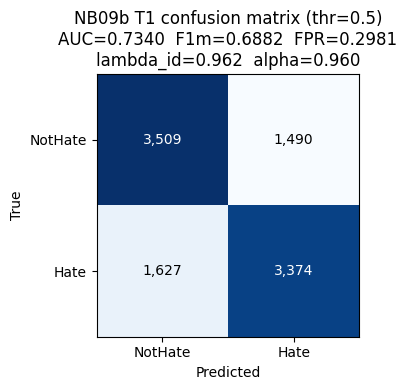

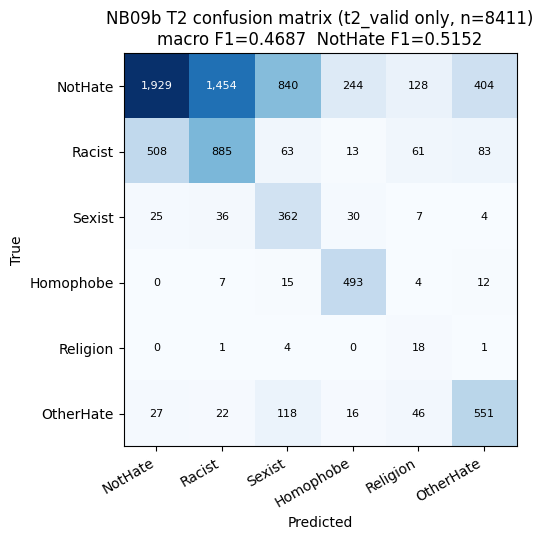

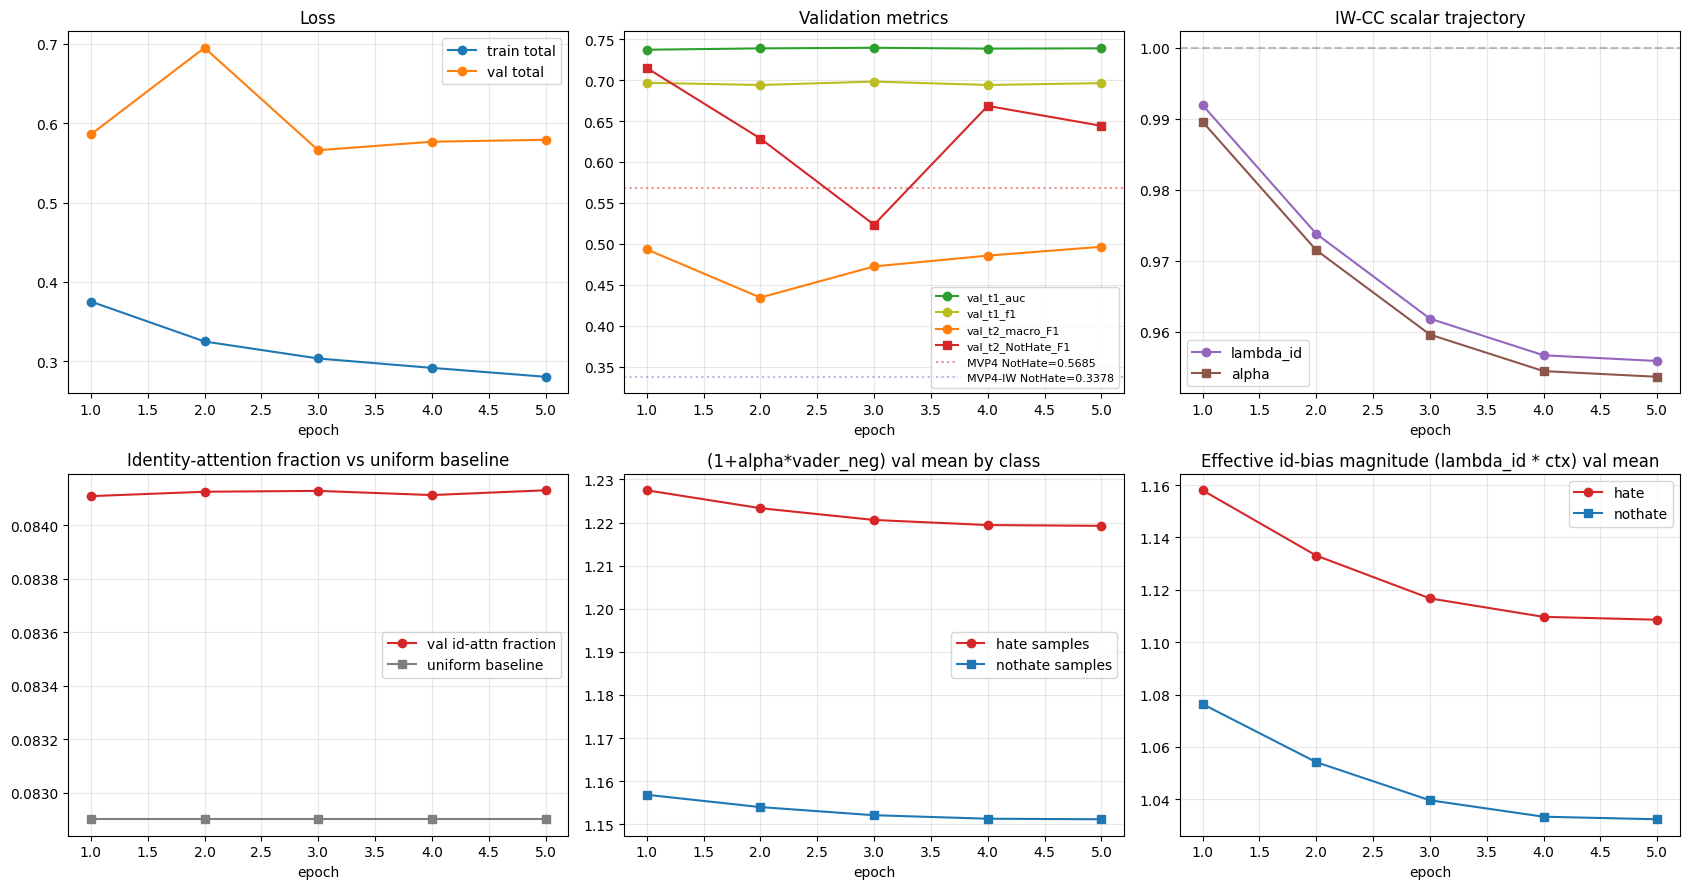

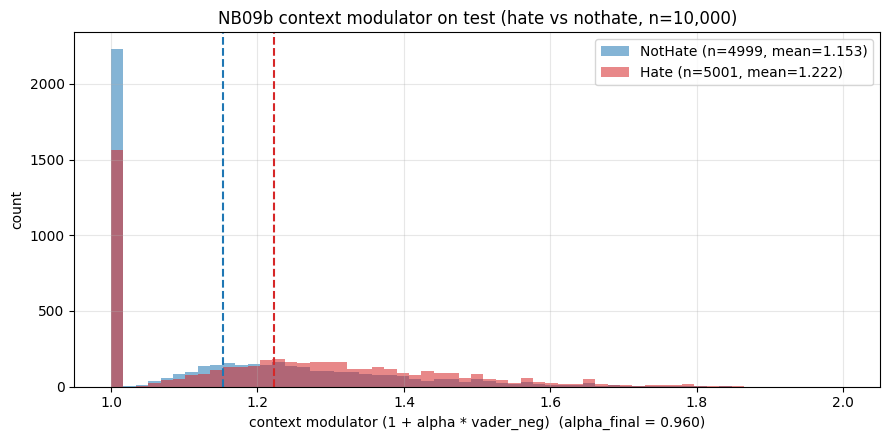

charts saved.


In [12]:
# Load best checkpoint
rest = torch.load(BEST_DIR / 'mvp4_iwcc_trainable.pt', map_location='cpu', weights_only=False)
model.struct_branch.load_state_dict(rest['struct_branch'])
model.cross_attn.load_state_dict(rest['cross_attn'])
model.cross_attn_ln.load_state_dict(rest['cross_attn_ln'])
model.gate.load_state_dict(rest['gate'])
model.proj_text.load_state_dict(rest['proj_text'])
model.proj_image.load_state_dict(rest['proj_image'])
model.proj_struct.load_state_dict(rest['proj_struct'])
model.head_t1.load_state_dict(rest['head_t1'])
model.head_t2.load_state_dict(rest['head_t2'])
model.to(device).eval()
lambda_id_final = float(model.cross_attn.lambda_id.detach().item())
alpha_final     = float(model.cross_attn.alpha.detach().item())
print(f'reloaded best (epoch {rest["epoch"]}, val_t1_auc={rest["val_t1_auc"]:.4f}, '
      f'val_t2_macro_f1={rest["val_t2_macro_f1"]:.4f}, val_gate_H={rest["val_gate_H"]:.4f})')
print(f'lambda_id (loaded): {lambda_id_final:.4f}   alpha (loaded): {alpha_final:.4f}')

# Test pass
t1_probs, t1_true = [], []
t2_preds, t2_true, t2_valid_arr = [], [], []
all_gates, tweet_ids_out = [], []
id_attn_fracs, uniform_baselines, ctx_mods = [], [], []
with torch.no_grad(), torch.amp.autocast('cuda', dtype=torch.float16):
    for batch in test_loader:
        ids  = batch['input_ids'].to(device, non_blocking=True)
        msk  = batch['attention_mask'].to(device, non_blocking=True)
        idm  = batch['identity_mask'].to(device, non_blocking=True)
        pix  = batch['pixel_values'].to(device, non_blocking=True)
        stc  = batch['structured'].to(device, non_blocking=True)
        vn   = batch['vader_neg_raw'].to(device, non_blocking=True)
        logit_t1, logits_t2, gates, lam_id, alpha_v, attn = model(
            ids, msk, pix, stc, idm, vn, return_attn=True)
        t1_probs.append(torch.sigmoid(logit_t1.view(-1).float()).cpu().numpy())
        t1_true.append(batch['t1_label'].cpu().numpy())
        t2_preds.append(logits_t2.argmax(dim=-1).cpu().numpy())
        t2_true.append(batch['t2_label'].cpu().numpy())
        t2_valid_arr.append(batch['t2_valid_mask'].cpu().numpy())
        all_gates.append(gates.float().cpu().numpy())
        tweet_ids_out.append(batch['tweet_id'].cpu().numpy())
        attn_mean = attn.float().mean(dim=1).squeeze(1)
        frac = (attn_mean * idm.float()).sum(dim=-1).cpu().numpy()
        base = (idm.float().sum(dim=-1) / msk.float().sum(dim=-1).clamp(min=1)).cpu().numpy()
        ctx  = (1.0 + alpha_v * vn.cpu().float()).numpy()
        id_attn_fracs.append(frac); uniform_baselines.append(base); ctx_mods.append(ctx)

all_t1_probs = np.concatenate(t1_probs); all_t1_true = np.concatenate(t1_true)
all_t2_preds = np.concatenate(t2_preds); all_t2_true = np.concatenate(t2_true)
all_t2_valid = np.concatenate(t2_valid_arr); all_gates = np.concatenate(all_gates, axis=0)
all_tweet_ids = np.concatenate(tweet_ids_out)
all_id_attn = np.concatenate(id_attn_fracs)
all_uniform = np.concatenate(uniform_baselines)
all_ctx_mod = np.concatenate(ctx_mods)
print(f'test preds: t1 {all_t1_probs.shape}, gates {all_gates.shape}, id_attn {all_id_attn.shape}, ctx_mod {all_ctx_mod.shape}')

# --- T1 metrics at threshold 0.5 ---
thr = HPARAMS['threshold']
all_t1_pred = (all_t1_probs >= thr).astype(int)
auc = roc_auc_score(all_t1_true, all_t1_probs)
f1m = f1_score(all_t1_true, all_t1_pred, average='macro')
pm  = precision_score(all_t1_true, all_t1_pred, average='macro', zero_division=0)
rm  = recall_score(all_t1_true, all_t1_pred, average='macro', zero_division=0)
cm  = confusion_matrix(all_t1_true, all_t1_pred, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()
fpr = fp / max(fp + tn, 1)
m_bal = {'AUC': float(auc), 'F1m': float(f1m), 'Pm': float(pm), 'Rm': float(rm), 'FPR': float(fpr),
         'TN': int(tn), 'FP': int(fp), 'FN': int(fn), 'TP': int(tp)}
print(f'\n--- T1 BALANCED-TEST metrics (thr={thr}) ---')
for k, v in m_bal.items():
    if isinstance(v, float): print(f'  {k:<5} {v:.4f}')
    else:                    print(f'  {k:<5} {v}')

# --- T2 metrics with per-class breakdown (NotHate is the key new diagnostic) ---
mask = all_t2_valid.astype(bool)
T2_CLASS_NAMES = ['NotHate', 'Racist', 'Sexist', 'Homophobe', 'Religion', 'OtherHate']
if mask.sum() > 0:
    t2_macro = f1_score(all_t2_true[mask], all_t2_preds[mask], average='macro',
                         labels=list(range(HPARAMS['n_t2_classes'])), zero_division=0)
    per_class = f1_score(all_t2_true[mask], all_t2_preds[mask], average=None,
                          labels=list(range(HPARAMS['n_t2_classes'])), zero_division=0)
    cm_t2 = confusion_matrix(all_t2_true[mask], all_t2_preds[mask],
                              labels=list(range(HPARAMS['n_t2_classes'])))
    print(f'\n--- T2 metrics (t2_valid=True only, n={int(mask.sum())}) ---')
    print(f'  macro F1: {t2_macro:.4f}')
    for c, f1c in zip(T2_CLASS_NAMES, per_class):
        marker = '  <-- key diagnostic' if c == 'NotHate' else ''
        print(f'  per-class F1  {c:<10} = {f1c:.4f}{marker}')
    t2_nothate_f1 = float(per_class[0])
else:
    t2_macro = float('nan'); per_class = np.full(HPARAMS['n_t2_classes'], np.nan); cm_t2 = None
    t2_nothate_f1 = float('nan')

# --- Identity attention split by hate / non-hate ---
hate_mask = (all_t1_true == 1)
nothate_mask = (all_t1_true == 0)
id_attn_hate    = float(all_id_attn[hate_mask].mean()) if hate_mask.any() else float('nan')
id_attn_nothate = float(all_id_attn[nothate_mask].mean()) if nothate_mask.any() else float('nan')
ctx_mod_hate    = float(all_ctx_mod[hate_mask].mean()) if hate_mask.any() else float('nan')
ctx_mod_nothate = float(all_ctx_mod[nothate_mask].mean()) if nothate_mask.any() else float('nan')

print('\n--- IDENTITY-ATTENTION ANALYSIS (test) ---')
print(f'  lambda_id (final): {lambda_id_final:.4f}   alpha (final): {alpha_final:.4f}')
print(f'  mean id-attention fraction (all):       {all_id_attn.mean():.4f}  (uniform baseline {all_uniform.mean():.4f})')
print(f'    HATE samples (n={int(hate_mask.sum())}):    {id_attn_hate:.4f}')
print(f'    NotHate samples (n={int(nothate_mask.sum())}): {id_attn_nothate:.4f}')
print(f'    delta (hate - nothate):                 {id_attn_hate - id_attn_nothate:+.4f}   '
      f'{"<-- context modulation IS working" if id_attn_hate > id_attn_nothate else "<-- context modulation NOT producing hate-skewed attention"}')
print(f'  mean (1+alpha*vader_neg) modulator:')
print(f'    HATE samples:    {ctx_mod_hate:.4f}')
print(f'    NotHate samples: {ctx_mod_nothate:.4f}')
print(f'    delta:           {ctx_mod_hate - ctx_mod_nothate:+.4f}')

# Gate stats (carry-over from NB09)
g_mean_test = all_gates.mean(axis=0)
g_std_test  = all_gates.std(axis=0)
gate_H_test = -(all_gates * np.log(all_gates + 1e-8)).sum(axis=-1)
print(f'\n--- TEST gate stats ---')
print(f'  mean: text={g_mean_test[0]:.4f}  image={g_mean_test[1]:.4f}  struct={g_mean_test[2]:.4f}')
print(f'  mean entropy: {gate_H_test.mean():.4f}  (log(3)={float(np.log(3.0)):.4f})')

# --- Save per-sample artefacts ---
np.save(MODEL_DIR / 'test_gates.npy',
        np.stack([all_tweet_ids.astype(np.int64),
                  all_gates[:, 0].astype(np.float32),
                  all_gates[:, 1].astype(np.float32),
                  all_gates[:, 2].astype(np.float32)], axis=1))
np.save(MODEL_DIR / 'test_identity_attention.npy',
        np.stack([all_tweet_ids.astype(np.int64),
                  all_id_attn.astype(np.float32),
                  all_uniform.astype(np.float32),
                  all_ctx_mod.astype(np.float32)], axis=1))
print(f'\nsaved test_gates.npy + test_identity_attention.npy (with context_modulator) to {MODEL_DIR}')

# --- Charts ---
# T1 confusion matrix
fig, ax = plt.subplots(figsize=(4.5, 4))
ax.imshow(cm, cmap='Blues')
for (i, j), v in np.ndenumerate(cm):
    ax.text(j, i, f'{v:,}', ha='center', va='center', color='black' if v < cm.max()/2 else 'white')
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(['NotHate', 'Hate']); ax.set_yticklabels(['NotHate', 'Hate'])
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title(f'NB09b T1 confusion matrix (thr={thr})\nAUC={auc:.4f}  F1m={f1m:.4f}  FPR={fpr:.4f}\nlambda_id={lambda_id_final:.3f}  alpha={alpha_final:.3f}')
plt.tight_layout()
plt.savefig(OUT_DIR / 'nb09b_t1_confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

# T2 confusion matrix
if cm_t2 is not None:
    fig, ax = plt.subplots(figsize=(6.5, 5.5))
    ax.imshow(cm_t2, cmap='Blues')
    for (i, j), v in np.ndenumerate(cm_t2):
        ax.text(j, i, f'{v:,}', ha='center', va='center',
                color='black' if v < cm_t2.max()/2 else 'white', fontsize=8)
    ax.set_xticks(range(HPARAMS['n_t2_classes'])); ax.set_yticks(range(HPARAMS['n_t2_classes']))
    ax.set_xticklabels(T2_CLASS_NAMES, rotation=30, ha='right')
    ax.set_yticklabels(T2_CLASS_NAMES)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title(f'NB09b T2 confusion matrix (t2_valid only, n={int(mask.sum())})\nmacro F1={t2_macro:.4f}  NotHate F1={t2_nothate_f1:.4f}')
    plt.tight_layout()
    plt.savefig(OUT_DIR / 'nb09b_t2_confusion_matrix.png', dpi=120, bbox_inches='tight')
    plt.show()

# Training curves: 2x3 panel (loss, val metrics, lambda_id, alpha, id-attn, context modulator hate/nothate)
hist = history; ep = hist['epoch']
fig, axes = plt.subplots(2, 3, figsize=(17, 9))
axes[0,0].plot(ep, hist['train_total'], label='train total', marker='o')
axes[0,0].plot(ep, hist['val_total'],   label='val total',   marker='o')
axes[0,0].set_title('Loss'); axes[0,0].set_xlabel('epoch'); axes[0,0].legend(); axes[0,0].grid(alpha=0.3)

axes[0,1].plot(ep, hist['val_t1_auc'], label='val_t1_auc',  marker='o', color='tab:green')
axes[0,1].plot(ep, hist['val_t1_f1'],  label='val_t1_f1',   marker='o', color='tab:olive')
axes[0,1].plot(ep, hist['val_t2_macro_f1'],   label='val_t2_macro_F1',   marker='o', color='tab:orange')
axes[0,1].plot(ep, hist['val_t2_nothate_f1'], label='val_t2_NotHate_F1', marker='s', color='tab:red')
axes[0,1].axhline(0.5685, color='tab:red', linestyle=':', alpha=0.5, label='MVP4 NotHate=0.5685')
axes[0,1].axhline(0.3378, color='tab:purple', linestyle=':', alpha=0.5, label='MVP4-IW NotHate=0.3378')
axes[0,1].set_title('Validation metrics'); axes[0,1].set_xlabel('epoch')
axes[0,1].legend(loc='lower right', fontsize=8); axes[0,1].grid(alpha=0.3)

axes[0,2].plot(ep, hist['lambda_id'], marker='o', color='tab:purple', label='lambda_id')
axes[0,2].plot(ep, hist['alpha'],     marker='s', color='tab:brown',  label='alpha')
axes[0,2].axhline(1.0, color='gray', linestyle='--', alpha=0.5)
axes[0,2].set_title('IW-CC scalar trajectory'); axes[0,2].set_xlabel('epoch')
axes[0,2].legend(); axes[0,2].grid(alpha=0.3)

axes[1,0].plot(ep, hist['val_id_attn_frac_mean'], label='val id-attn fraction', marker='o', color='tab:red')
axes[1,0].plot(ep, hist['val_uniform_baseline_mean'], label='uniform baseline', marker='s', color='tab:gray')
axes[1,0].set_title('Identity-attention fraction vs uniform baseline'); axes[1,0].set_xlabel('epoch')
axes[1,0].legend(); axes[1,0].grid(alpha=0.3)

axes[1,1].plot(ep, hist['val_ctx_mod_mean_hate'],    label='hate samples',    marker='o', color='tab:red')
axes[1,1].plot(ep, hist['val_ctx_mod_mean_nothate'], label='nothate samples', marker='s', color='tab:blue')
axes[1,1].set_title('(1+alpha*vader_neg) val mean by class'); axes[1,1].set_xlabel('epoch')
axes[1,1].legend(); axes[1,1].grid(alpha=0.3)

axes[1,2].plot(ep, hist['val_bias_mag_mean_hate'],    label='hate',    marker='o', color='tab:red')
axes[1,2].plot(ep, hist['val_bias_mag_mean_nothate'], label='nothate', marker='s', color='tab:blue')
axes[1,2].set_title('Effective id-bias magnitude (lambda_id * ctx) val mean'); axes[1,2].set_xlabel('epoch')
axes[1,2].legend(); axes[1,2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR / 'nb09b_training_curves.png', dpi=120, bbox_inches='tight')
plt.show()

# Context modulation histogram (test set, hate vs non-hate)
fig, ax = plt.subplots(figsize=(9, 4.5))
bins = np.linspace(min(1.0, all_ctx_mod.min()), max(2.0, all_ctx_mod.max()), 60)
ax.hist(all_ctx_mod[nothate_mask], bins=bins, alpha=0.55, color='tab:blue',
        label=f'NotHate (n={int(nothate_mask.sum())}, mean={ctx_mod_nothate:.3f})')
ax.hist(all_ctx_mod[hate_mask],    bins=bins, alpha=0.55, color='tab:red',
        label=f'Hate (n={int(hate_mask.sum())}, mean={ctx_mod_hate:.3f})')
ax.axvline(ctx_mod_nothate, color='tab:blue', linestyle='--')
ax.axvline(ctx_mod_hate,    color='tab:red',  linestyle='--')
ax.set_xlabel(f'context modulator (1 + alpha * vader_neg)  (alpha_final = {alpha_final:.3f})')
ax.set_ylabel('count')
ax.set_title(f'NB09b context modulator on test (hate vs nothate, n={len(all_ctx_mod):,})')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / 'nb09b_context_modulation.png', dpi=120, bbox_inches='tight')
plt.show()

print('charts saved.')

In [13]:
prior_hate    = HPARAMS['prior_hate']
prior_nothate = HPARAMS['prior_nothate']

def recalibrate(p, ph=prior_hate, pn=prior_nothate):
    num = p * ph
    den = num + (1 - p) * pn
    return num / np.maximum(den, 1e-12)

v_probs, v_true = [], []
with torch.no_grad(), torch.amp.autocast('cuda', dtype=torch.float16):
    for batch in val_loader:
        ids = batch['input_ids'].to(device, non_blocking=True)
        msk = batch['attention_mask'].to(device, non_blocking=True)
        idm = batch['identity_mask'].to(device, non_blocking=True)
        pix = batch['pixel_values'].to(device, non_blocking=True)
        stc = batch['structured'].to(device, non_blocking=True)
        vn  = batch['vader_neg_raw'].to(device, non_blocking=True)
        logit_t1, _, _, _, _ = model(ids, msk, pix, stc, idm, vn)
        v_probs.append(torch.sigmoid(logit_t1.view(-1).float()).cpu().numpy())
        v_true.append(batch['t1_label'].cpu().numpy())
val_probs_arr = np.concatenate(v_probs); val_true_arr = np.concatenate(v_true)

test_probs_recal = recalibrate(all_t1_probs)
val_probs_recal  = recalibrate(val_probs_arr)

best_thr, best_thr_f1 = 0.5, -1.0
for t in np.linspace(0.01, 0.99, 99):
    pred = (val_probs_recal >= t).astype(int)
    fv = f1_score(val_true_arr, pred)
    if fv > best_thr_f1:
        best_thr_f1 = fv; best_thr = float(t)
print(f'F1-opt threshold on RECALIBRATED VAL: {best_thr:.3f} (val F1={best_thr_f1:.4f})')
print(f'  recal val prob range:  [{val_probs_recal.min():.4f}, {val_probs_recal.max():.4f}]  mean={val_probs_recal.mean():.4f}')
print(f'  recal test prob range: [{test_probs_recal.min():.4f}, {test_probs_recal.max():.4f}]  mean={test_probs_recal.mean():.4f}')

pred_recal = (test_probs_recal >= best_thr).astype(int)
auc_r = roc_auc_score(all_t1_true, test_probs_recal)
f1m_r = f1_score(all_t1_true, pred_recal, average='macro')
pm_r  = precision_score(all_t1_true, pred_recal, average='macro', zero_division=0)
rm_r  = recall_score(all_t1_true, pred_recal, average='macro', zero_division=0)
cm_r  = confusion_matrix(all_t1_true, pred_recal, labels=[0, 1])
tn_r, fp_r, fn_r, tp_r = cm_r.ravel()
fpr_r = fp_r / max(fp_r + tn_r, 1)
m_rec = {'AUC': float(auc_r), 'F1m': float(f1m_r), 'Pm': float(pm_r), 'Rm': float(rm_r), 'FPR': float(fpr_r),
         'TN': int(tn_r), 'FP': int(fp_r), 'FN': int(fn_r), 'TP': int(tp_r), 'threshold': float(best_thr)}

print('\n--- BALANCED-TEST  vs  RECALIBRATED-TEST  T1 metrics ---')
print(f'  {"":<7} {"balanced (thr=0.5)":>22} {"recalibrated (thr opt)":>24}')
for k in ['AUC', 'F1m', 'Pm', 'Rm', 'FPR']:
    print(f'  {k:<7} {m_bal[k]:>22.4f} {m_rec[k]:>24.4f}')
print(f'  CM bal: TN={m_bal["TN"]} FP={m_bal["FP"]} FN={m_bal["FN"]} TP={m_bal["TP"]}')
print(f'  CM rec: TN={m_rec["TN"]} FP={m_rec["FP"]} FN={m_rec["FN"]} TP={m_rec["TP"]} (thr={best_thr:.3f})')

F1-opt threshold on RECALIBRATED VAL: 0.210 (val F1=0.7018)
  recal val prob range:  [0.0417, 0.4522]  mean=0.2543
  recal test prob range: [0.0428, 0.4569]  mean=0.2557

--- BALANCED-TEST  vs  RECALIBRATED-TEST  T1 metrics ---
              balanced (thr=0.5)   recalibrated (thr opt)
  AUC                     0.7340                   0.7340
  F1m                     0.6882                   0.6719
  Pm                      0.6884                   0.6773
  Rm                      0.6883                   0.6736
  FPR                     0.2981                   0.3991
  CM bal: TN=3509 FP=1490 FN=1627 TP=3374
  CM rec: TN=3004 FP=1995 FN=1269 TP=3732 (thr=0.210)


In [14]:
# Six-row comparison (T2 NotHate F1 marked 'n/a' for MVP2/MVP3 — not stored in those metrics.json)
mvp1   = {'AUC': 0.7431, 'F1m': 0.6855, 'FPR': 0.2667, 'T2': None,   'T2_NotHate': None,   'label': 'MVP 1 (text only)'}
mvp2   = {'AUC': 0.7411, 'F1m': 0.6892, 'FPR': 0.3041, 'T2': 0.3795, 'T2_NotHate': None,   'label': 'MVP 2 (T+I naive)'}
mvp3   = {'AUC': 0.7406, 'F1m': 0.6905, 'FPR': 0.3361, 'T2': 0.4787, 'T2_NotHate': None,   'label': 'MVP 3 (T+I+S naive)'}
mvp4   = {'AUC': 0.7400, 'F1m': 0.6888, 'FPR': 0.3071, 'T2': 0.4933, 'T2_NotHate': 0.5685, 'label': 'MVP 4 (gated)'}
mvp4iw = {'AUC': 0.7359, 'F1m': 0.6876, 'FPR': 0.2857, 'T2': 0.4308, 'T2_NotHate': 0.3378, 'label': 'MVP 4-IW (NB09)'}
this   = {'AUC': m_bal['AUC'], 'F1m': m_bal['F1m'], 'FPR': m_bal['FPR'],
          'T2': float(t2_macro) if not (isinstance(t2_macro, float) and math.isnan(t2_macro)) else None,
          'T2_NotHate': t2_nothate_f1,
          'label': 'MVP 4-IW-CC (this)'}

def fmt(v):
    return f'{v:.4f}' if isinstance(v, (int, float)) and v is not None else 'n/a'

rows = [mvp1, mvp2, mvp3, mvp4, mvp4iw, this]
print('=== 6-row comparison (balanced 50/50 test, thr=0.5) ===')
print(f'  {"":<24} {"AUC":>8} {"F1m":>8} {"FPR":>8} {"T2":>8} {"T2_NH":>8}')
for r in rows:
    print(f'  {r["label"]:<24} {fmt(r["AUC"]):>8} {fmt(r["F1m"]):>8} {fmt(r["FPR"]):>8} {fmt(r["T2"]):>8} {fmt(r["T2_NotHate"]):>8}')

# Deltas vs MVP4-IW (primary comparison) and vs MVP4 (original baseline)
def delta(a, b): return None if (a is None or b is None) else a - b
def dfmt(d): return 'n/a' if d is None else f'{d:+.4f}'

print('\nDeltas vs MVP 4-IW (primary comparison):')
for k in ['AUC', 'F1m', 'FPR', 'T2', 'T2_NotHate']:
    print(f'  d_{k:<10} = {dfmt(delta(this[k], mvp4iw[k]))}')
print('\nDeltas vs MVP 4 (original baseline):')
for k in ['AUC', 'F1m', 'FPR', 'T2', 'T2_NotHate']:
    print(f'  d_{k:<10} = {dfmt(delta(this[k], mvp4[k]))}')

# Success criteria (4 axes)
crit_a = this['AUC'] >= mvp4iw['AUC']
crit_b = (this['T2_NotHate'] is not None) and (this['T2_NotHate'] >= 0.45)
crit_c = abs(this['FPR'] - mvp4iw['FPR']) <= 0.02
crit_d = alpha_final > 0.1

print('\n=== FOUR SUCCESS CRITERIA ===')
print(f'  (a) AUC >= MVP 4-IW (0.7359):           {fmt(this["AUC"])} vs 0.7359   -> {"PASS" if crit_a else "FAIL"}')
print(f'  (b) T2 NotHate F1 >= 0.45:              {fmt(this["T2_NotHate"])}            -> {"PASS" if crit_b else "FAIL"}')
print(f'  (c) FPR within 0.02 of MVP 4-IW (0.2857): {fmt(this["FPR"])} (|delta|={abs(this["FPR"]-mvp4iw["FPR"]):.4f})  -> {"PASS" if crit_c else "FAIL"}')
print(f'  (d) alpha > 0.1 at convergence:         alpha_final={alpha_final:.4f}            -> {"PASS" if crit_d else "FAIL"}')
n_pass = int(crit_a) + int(crit_b) + int(crit_c) + int(crit_d)
print(f'\n  PASS COUNT: {n_pass}/4')

# Honest verdict
nothate_recovered_partial = (this['T2_NotHate'] is not None) and (this['T2_NotHate'] > mvp4iw['T2_NotHate'])
auc_cost  = mvp4iw['AUC'] - this['AUC']
fpr_cost  = this['FPR']  - mvp4iw['FPR']
verdict_lines = []
if n_pass == 0:
    verdict_lines.append('VARIANT REJECTED: context modulation did not deliver on any of the four axes.')
elif n_pass == 4:
    verdict_lines.append('STRONG WIN: context modulation passes all four criteria — recovers T2 NotHate, preserves AUC and FPR, alpha learned to remain meaningful.')
else:
    verdict_lines.append(f'PARTIAL WIN ({n_pass}/4 criteria). What context modulation achieved vs what it cost:')
    if crit_b:
        verdict_lines.append(f'  + T2 NotHate F1 recovered to {this["T2_NotHate"]:.4f} (from MVP 4-IW 0.3378)')
    elif nothate_recovered_partial:
        verdict_lines.append(f'  ~ T2 NotHate F1 moved to {this["T2_NotHate"]:.4f} (better than MVP 4-IW 0.3378, but below 0.45 target)')
    else:
        verdict_lines.append(f'  - T2 NotHate F1 did not recover ({fmt(this["T2_NotHate"])})')
    if crit_a:
        verdict_lines.append(f'  + AUC preserved ({this["AUC"]:.4f} >= 0.7359)')
    else:
        verdict_lines.append(f'  - AUC degraded by {auc_cost:+.4f} below MVP 4-IW')
    if crit_c:
        verdict_lines.append(f'  + FPR within 0.02 of MVP 4-IW ({this["FPR"]:.4f} vs 0.2857)')
    else:
        verdict_lines.append(f'  - FPR drifted {fpr_cost:+.4f} from MVP 4-IW (broke FPR-preservation criterion)')
    if crit_d:
        verdict_lines.append(f'  + alpha_final={alpha_final:.4f} > 0.1 -> context modulation mechanism was actively used')
    else:
        verdict_lines.append(f'  - alpha_final={alpha_final:.4f} below 0.1 -> mechanism essentially pruned; result ~ MVP 4-IW')

verdict = '\n  '.join(verdict_lines)
print('\n=== HONEST VERDICT ===')
print('  ' + verdict)

# Save artefacts
shutil.copy(BEST_DIR / 'mvp4_iwcc_trainable.pt', MODEL_DIR / 'mvp4_iwcc_trainable.pt')
shutil.copy(BEST_DIR / 'standardisation_stats.json', MODEL_DIR / 'standardisation_stats.json')

with open(MODEL_DIR / 'hparams.json', 'w') as f:
    json.dump({k: v for k, v in HPARAMS.items() if not k.startswith('_')}, f, indent=2)
with open(MODEL_DIR / 'training_history.json', 'w') as f:
    json.dump(history, f, indent=2)

metrics_payload = {
    'run_label': 'mvp4_iwcc_attention',
    'best_epoch': int(best_epoch),
    'best_val_t1_auc': float(best_t1_auc),
    'best_val_t2_macro_f1': float(history['val_t2_macro_f1'][best_epoch - 1]) if best_epoch >= 1 else None,
    'best_val_t2_nothate_f1': float(history['val_t2_nothate_f1'][best_epoch - 1]) if best_epoch >= 1 else None,
    't1_pos_weight': float(pos_weight_value),
    't1_thresholds': {'balanced_headline': 0.5, 'recal_f1_optimised_on_recal_val': float(best_thr)},
    'priors_for_recalibration': {'hate': prior_hate, 'nothate': prior_nothate},
    't1_balanced_test_thr_0.5':       m_bal,
    't1_recalibrated_test_thr_opt':   m_rec,
    't2_test_macro_f1_valid_only':    float(t2_macro),
    't2_test_nothate_f1':             float(t2_nothate_f1),
    't2_test_per_class_f1':           {c: float(v) for c, v in zip(T2_CLASS_NAMES, per_class)},
    't2_test_n_valid':                int(mask.sum()),
    'loss_weights': {'t1': HPARAMS['t1_weight'], 't2': HPARAMS['t2_weight'], 'entropy': HPARAMS['entropy_weight']},
    'iwcc_specific': {
        'lambda_id_init':  float(HPARAMS['lambda_id_init']),
        'lambda_id_final': lambda_id_final,
        'alpha_init':      float(HPARAMS['alpha_init']),
        'alpha_final':     alpha_final,
        'mean_identity_attention_fraction_test':         float(all_id_attn.mean()),
        'mean_identity_attention_fraction_test_hate':    id_attn_hate,
        'mean_identity_attention_fraction_test_nothate': id_attn_nothate,
        'mean_uniform_baseline_test':                    float(all_uniform.mean()),
        'mean_ctx_modulator_test_hate':                  ctx_mod_hate,
        'mean_ctx_modulator_test_nothate':               ctx_mod_nothate,
        'lift_over_uniform': float(all_id_attn.mean() / max(all_uniform.mean(), 1e-8)),
    },
    'comparison': {
        'mvp1': mvp1, 'mvp2': mvp2, 'mvp3': mvp3, 'mvp4': mvp4, 'mvp4_iw': mvp4iw, 'mvp4_iwcc': this,
        'delta_vs_mvp4_iw':     {k: delta(this[k], mvp4iw[k]) for k in ['AUC','F1m','FPR','T2','T2_NotHate']},
        'delta_vs_mvp4':        {k: delta(this[k], mvp4[k])   for k in ['AUC','F1m','FPR','T2','T2_NotHate']},
        'criterion_a_auc_no_drop':        bool(crit_a),
        'criterion_b_nothate_f1_geq_045': bool(crit_b),
        'criterion_c_fpr_within_002':     bool(crit_c),
        'criterion_d_alpha_meaningful':   bool(crit_d),
        'n_success_axes_passed':          int(n_pass),
        'verdict':                        verdict,
    },
}
with open(MODEL_DIR / 'metrics.json', 'w') as f:
    json.dump(metrics_payload, f, indent=2)

final_iwcc_stats = {
    'lambda_id_init': float(HPARAMS['lambda_id_init']),
    'lambda_id_final': lambda_id_final,
    'alpha_init': float(HPARAMS['alpha_init']),
    'alpha_final': alpha_final,
    'gate_mean':  {'text': float(g_mean_test[0]), 'image': float(g_mean_test[1]), 'struct': float(g_mean_test[2])},
    'gate_std':   {'text': float(g_std_test[0]),  'image': float(g_std_test[1]),  'struct': float(g_std_test[2])},
    'mean_gate_entropy_test': float(gate_H_test.mean()),
    'max_gate_entropy_log3':  float(np.log(3.0)),
    'mean_id_attention_fraction_test': float(all_id_attn.mean()),
    'mean_id_attention_fraction_test_hate':    id_attn_hate,
    'mean_id_attention_fraction_test_nothate': id_attn_nothate,
    'mean_uniform_baseline_test':      float(all_uniform.mean()),
    'mean_ctx_modulator_test_hate':    ctx_mod_hate,
    'mean_ctx_modulator_test_nothate': ctx_mod_nothate,
    'n_test': int(len(all_id_attn)),
}
with open(MODEL_DIR / 'iwcc_stats.json', 'w') as f:
    json.dump(final_iwcc_stats, f, indent=2)

print(f'\nartifacts saved to {MODEL_DIR}:')
for p in sorted(MODEL_DIR.iterdir()):
    sz_kb = p.stat().st_size / 1024
    print(f'  {p.name:<35} {sz_kb:>10.1f} KB')
print(f'best checkpoint:        {BEST_DIR / "mvp4_iwcc_trainable.pt"}')
print('\nDONE.')

=== 6-row comparison (balanced 50/50 test, thr=0.5) ===
                                AUC      F1m      FPR       T2    T2_NH
  MVP 1 (text only)          0.7431   0.6855   0.2667      n/a      n/a
  MVP 2 (T+I naive)          0.7411   0.6892   0.3041   0.3795      n/a
  MVP 3 (T+I+S naive)        0.7406   0.6905   0.3361   0.4787      n/a
  MVP 4 (gated)              0.7400   0.6888   0.3071   0.4933   0.5685
  MVP 4-IW (NB09)            0.7359   0.6876   0.2857   0.4308   0.3378
  MVP 4-IW-CC (this)         0.7340   0.6882   0.2981   0.4687   0.5152

Deltas vs MVP 4-IW (primary comparison):
  d_AUC        = -0.0019
  d_F1m        = +0.0006
  d_FPR        = +0.0124
  d_T2         = +0.0379
  d_T2_NotHate = +0.1774

Deltas vs MVP 4 (original baseline):
  d_AUC        = -0.0060
  d_F1m        = -0.0006
  d_FPR        = -0.0090
  d_T2         = -0.0246
  d_T2_NotHate = -0.0533

=== FOUR SUCCESS CRITERIA ===
  (a) AUC >= MVP 4-IW (0.7359):           0.7340 vs 0.7359   -> FAIL
  (b) T2 N